# Lake Kinneret Environmental Analysis
## Comprehensive PCA, Cellular Automata, and Scenario Visualization

This notebook integrates:
- E.coli and Flood data analysis
- Heavy Metals analysis
- Chemical parameters (Chloride, Nitrate, Lake Level, Depth)
- PCA biplot visualization
- Cellular Automata ecological modeling
- Comprehensive scenario analysis

## Imports & Firebase Connection

In [ ]:
# Import all required libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.animation import PillowWriter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from IPython.display import HTML, display
import random
import warnings
from typing import Optional, List, Dict
import requests
import json
import firebase_admin
from firebase_admin import credentials, db
import os
from google.colab import files
#!pip install firebase-admin

warnings.filterwarnings('ignore')

# Set matplotlib parameters
import matplotlib as mpl
mpl.rcParams['animation.html'] = 'jshtml'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 0.8

In [ ]:
# Configuration
file_id = "1SOecotcP3AgKSZWSREZU4dpCMS7DX-Ux"
DATABASE_URL = "https://ecofishdb-default-rtdb.firebaseio.com/"

def load_data_from_firebase():
    """Load data from Firebase using Google Drive service account"""
    try:
        # Download service account JSON from Google Drive
        download_url = f"https://drive.google.com/uc?id={file_id}&export=download"
        print("Downloading service account from Google Drive...")

        response = requests.get(download_url)
        response.raise_for_status()

        # Parse JSON content directly (no file saving needed)
        service_account_info = response.json()
        print("Service account loaded successfully")

        # Initialize Firebase
        if not firebase_admin._apps:
            cred = credentials.Certificate(service_account_info)
            firebase_admin.initialize_app(cred, {
                'databaseURL': DATABASE_URL
            })

        # Get data
        ref = db.reference('/')
        data = ref.get()

        if data:
            print("Connected to Firebase successfully")
            print(f"Available data keys: {list(data.keys())}")
            return data
        else:
            print("Connected but no data found")
            return None

    except Exception as e:
        print(f"Error: {e}")
        return None

# Execute
print("Connecting to Firebase Realtime Database...")
data = load_data_from_firebase()
has_real_data = data is not None

Connecting to Firebase Realtime Database...
Service account loaded successfully
Connected to Firebase successfully
Available data keys: ['Chemicals_Height', 'Ecolifloods', 'GEMINI_API_KEY', 'Heavy_Metals']


In [ ]:
# Load and examine data structure
print("Available data keys:", list(data.keys()))

Available data keys: ['Chemicals_Height', 'Ecolifloods', 'GEMINI_API_KEY', 'Heavy_Metals']


In [ ]:
# Utility function for safe data conversion
def safe_float_convert(value):
    """
    Safely convert various data formats to float values.
    Handles special cases like 'TNTC', 'ND', 'BDL', and '<' prefixed values.
    """
    if value is None:
        return None
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        value_upper = value.upper().strip()
        if value_upper == 'TNTC':
            return 1000.0
        if value_upper in ['ND', 'BDL']:
            return 0.1
        if value_upper.startswith('<'):
            try:
                return float(value_upper[1:]) * 0.5
            except Exception:
                return 0.1
        try:
            return float(value)
        except ValueError:
            return None
    return None

## PCA Analysis and Biplot Creation

PCA analyzes the correlation matrix of all environmental variables to find the linear combinations that explain maximum variance. Each variable gets "loadings" (weights) that determine arrow direction - positive loadings point toward positive PC direction, negative loadings point opposite. When a PC score increases, variables with positive loadings increase above their average while variables with negative loadings decrease below average. Arrow directions show correlations: same direction = positive correlation, opposite = negative correlation, perpendicular = no correlation. The PC scores become environmental condition indices where each year gets a single number representing its position along major patterns of environmental variation.
PCA Implementation:

Z-Score Standardization: Converts all variables to standard units where Z-Score = (actual value - mean) / standard deviation, allowing comparison between different measurement units (CFU/100ml, µg/L, meters)
PC Score Calculation: Each year gets a single score by multiplying each variable's Z-score by its loading weight: PC1_Score = (E.coli_Z × weight) + (Lead_Z × weight) + (all other variables...)
Variance Explanation: Shows what percentage of total environmental variation each PC explains

In [ ]:
def create_pca_biplot(json_file='firebase.json'):
    """
    Create improved PCA biplot with better label positioning and visualization
    """
    import json
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    from sklearn.impute import SimpleImputer
    from adjustText import adjust_text  # For automatic label positioning
    import matplotlib.patches as patches

    def safe_float_convert(value):
        """Safe conversion to float"""
        if value is None:
            return None
        try:
            return float(value)
        except (ValueError, TypeError):
            return None

    def adjust_labels_positions(ax, arrows_data, labels_data, scale=3.5):
        """Adjust label positions to avoid overlaps"""
        adjusted_positions = []

        for i, (arrow_data, label_data) in enumerate(zip(arrows_data, labels_data)):
            x_pos = arrow_data['x'] * scale * 1.2
            y_pos = arrow_data['y'] * scale * 1.2

            # Check for overlaps and adjust
            for prev_pos in adjusted_positions:
                distance = np.sqrt((x_pos - prev_pos['x'])**2 + (y_pos - prev_pos['y'])**2)
                if distance < 0.8:  # Minimum distance threshold
                    # Adjust position
                    angle = np.arctan2(y_pos, x_pos)
                    x_pos = prev_pos['x'] + 0.8 * np.cos(angle + 0.3)
                    y_pos = prev_pos['y'] + 0.8 * np.sin(angle + 0.3)

            adjusted_positions.append({'x': x_pos, 'y': y_pos, 'label': label_data['text'], 'color': label_data['color']})

        return adjusted_positions

    try:
        with open(json_file, encoding='utf-8') as f:
            data = json.load(f)

        # Process E.coli and flood data
        ecoli_grouped = None
        if 'Ecolifloods' in data:
            ecoli_records = []
            for year, year_data in data['Ecolifloods'].items():
                if not isinstance(year_data, list):
                    continue
                for month_obj in year_data:
                    if not isinstance(month_obj, dict):
                        continue
                    for _, day_list in month_obj.items():
                        if not isinstance(day_list, list):
                            continue
                        for rec in day_list:
                            if not isinstance(rec, dict):
                                continue
                            ecoli_val = safe_float_convert(rec.get('Ecoli'))
                            flood = rec.get('flood_in_month', 0)
                            if ecoli_val is None:
                                continue
                            try:
                                ecoli_records.append({
                                    'year': int(year),
                                    'ecoli': float(ecoli_val),
                                    'flood': int(flood) if flood is not None else 0
                                })
                            except (ValueError, TypeError):
                                pass
            if ecoli_records:
                ecoli_df = pd.DataFrame(ecoli_records)
                ecoli_grouped = ecoli_df.groupby('year').agg(
                    ecoli=('ecoli', 'mean'),
                    flood=('flood', 'max')
                ).reset_index()

        # Process heavy metals data
        metals_grouped = None
        if 'Heavy_Metals' in data:
            metals_records = []
            for site_key, site_blob in data['Heavy_Metals'].items():
                if not isinstance(site_blob, dict):
                    continue
                for year_key, year_blob in site_blob.items():
                    days_dict = None
                    if isinstance(year_blob, list):
                        for item in year_blob:
                            if isinstance(item, dict):
                                days_dict = item
                                break
                    elif isinstance(year_blob, dict):
                        days_dict = year_blob
                    if not isinstance(days_dict, dict):
                        continue
                    for _, day_list in days_dict.items():
                        if not isinstance(day_list, list):
                            continue
                        for record in day_list:
                            if not isinstance(record, dict):
                                continue
                            row = {'year': int(year_key)}
                            for k_json, k_out in [
                                ('Cu_µg_L', 'Cu'), ('Pb_µg_L', 'Pb'), ('Al_µg_L', 'Al'),
                                ('Cd_µg_L', 'Cd'), ('Fe_µg_L', 'Fe'), ('Hg_µg_L', 'Hg'),
                                ('Mn_µg_L', 'Mn'), ('Zn_µg_L', 'Zn'),
                                ('Depth_m', 'Depth')
                            ]:
                                v = record.get(k_json)
                                if v is not None:
                                    try:
                                        row[k_out] = float(v)
                                    except (ValueError, TypeError):
                                        pass
                            if len(row) > 1:
                                metals_records.append(row)
            if metals_records:
                metals_df = pd.DataFrame(metals_records)
                metal_cols = [c for c in metals_df.columns if c != 'year']
                metals_grouped = metals_df.groupby('year')[metal_cols].mean().reset_index()

        # Process chemical data (including Nitrate)
        chem_grouped = None
        if 'Chemicals_Height' in data:
            chem_records = []
            for year_key, year_blob in data['Chemicals_Height'].items():
                days_dict = None
                if isinstance(year_blob, list):
                    for item in year_blob:
                        if isinstance(item, dict):
                            days_dict = item
                            break
                elif isinstance(year_blob, dict):
                    days_dict = year_blob
                if not isinstance(days_dict, dict):
                    continue
                for _, rec_list in days_dict.items():
                    if not isinstance(rec_list, list):
                        continue
                    for rec in rec_list:
                        if not isinstance(rec, dict):
                            continue
                        row = {'year': int(year_key)}
                        for k in ('chl_ug_l_avg', 'avg_nitrate', 'kineret_height'):
                            v = rec.get(k)
                            if v is not None:
                                try:
                                    row[k] = float(v)
                                except (ValueError, TypeError):
                                    pass
                        if len(row) > 1:
                            chem_records.append(row)
            if chem_records:
                chem_df = pd.DataFrame(chem_records)
                available_cols = [col for col in ['chl_ug_l_avg', 'avg_nitrate', 'kineret_height'] if col in chem_df.columns]
                if available_cols:
                    chem_grouped = chem_df.groupby('year')[available_cols].mean().reset_index()

        # Merge all data (same as before)
        parts = [('ecoli', ecoli_grouped), ('metals', metals_grouped), ('chem', chem_grouped)]
        parts = [(name, df) for name, df in parts if df is not None]
        if not parts:
            raise ValueError("No valid data found to merge")

        base_name, base = max(parts, key=lambda t: len(t[1]))
        final_data = base.copy()

        for name, df in parts:
            if df is final_data:
                continue
            final_data = final_data.merge(df, on='year', how='left', suffixes=('', f'_{name}'))

        # Clean up duplicate columns
        cols = set(final_data.columns)
        dupe_pairs = []
        for c in list(final_data.columns):
            if c.endswith('_x'):
                base = c[:-2]
                ycol = base + '_y'
                if ycol in cols:
                    dupe_pairs.append((base, c, ycol))
        for base, xcol, ycol in dupe_pairs:
            final_data[base] = final_data[xcol].combine_first(final_data[ycol])
            final_data.drop([xcol, ycol], axis=1, inplace=True)

        # Consolidate similar columns
        base_like = {}
        for c in list(final_data.columns):
            if '_' in c and c != 'kineret_height':
                base = c.split('_')[0]
                base_like.setdefault(base, set()).add(c)
        for base, variants in base_like.items():
            if base in final_data.columns:
                for v in variants:
                    if v in final_data.columns:
                        final_data[base] = final_data[base].combine_first(final_data[v])
                        final_data.drop(v, axis=1, inplace=True)

        # Clean data and prepare for PCA
        non_year_cols = [c for c in final_data.columns if c != 'year']
        final_data = final_data.dropna(subset=non_year_cols, how='all')

        feature_candidates = [c for c in final_data.columns if c != 'year']
        final_data_numeric = final_data.copy()
        for c in feature_candidates:
            final_data_numeric[c] = pd.to_numeric(final_data_numeric[c], errors='coerce')

        # Select key variables
        must_have = ['Pb','Zn','Depth','chl_ug_l_avg','avg_nitrate','kineret_height','ecoli','flood']
        selected = [c for c in must_have if c in final_data_numeric.columns]

        if len(selected) < 2:
            coverage = final_data_numeric[feature_candidates].notna().mean()
            extras = [c for c in coverage.sort_values(ascending=False).index if c not in selected]
            selected.extend(extras[:max(0, 2-len(selected))])

        print(f"Selected features for PCA: {selected}")

        # Impute missing values and run PCA
        X = final_data_numeric[selected].to_numpy(dtype=float)
        imputer = SimpleImputer(strategy='median')
        X_imputed = imputer.fit_transform(X)

        scaler = StandardScaler()
        X_std = scaler.fit_transform(X_imputed)

        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_std)

        # Create improved biplot
        plt.style.use('default')
        fig, ax = plt.subplots(figsize=(16, 12))

        # Enhanced color scheme - more distinct colors
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57',
                 '#FF9FF3', '#54A0FF', '#5F27CD', '#1DD1A1', '#FD79A8',
                 '#FDCB6E', '#6C5CE7', '#A29BFE', '#74B9FF']

        # Improved labels dictionary
        labels = {
            'ecoli': 'E.coli',
            'flood': 'Flood Risk',
            'Cu': 'Copper', 'Pb': 'Lead', 'Al': 'Aluminum', 'Cd': 'Cadmium',
            'Fe': 'Iron', 'Hg': 'Mercury', 'Mn': 'Manganese', 'Zn': 'Zinc',
            'Depth': 'Depth',
            'chl_ug_l_avg': 'Chloride',
            'avg_nitrate': 'Nitrate',
            'kineret_height': 'Lake Level'
        }

        # Add scatter points for observations (years) with better styling
        years = final_data['year'].values
        scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                           c=years, cmap='viridis',
                           s=120, alpha=0.8, edgecolors='white', linewidth=2,
                           zorder=5)

        # Prepare data for arrows and labels
        scale = 4.0
        arrows_data = []
        labels_data = []

        # Draw arrows first
        for i, feat in enumerate(selected):
            color = colors[i % len(colors)]
            x_arrow = pca.components_[0, i] * scale
            y_arrow = pca.components_[1, i] * scale

            # Draw arrow with better styling
            ax.arrow(0, 0, x_arrow, y_arrow,
                    head_width=0.15, head_length=0.18,
                    fc=color, ec=color,
                    alpha=0.9, linewidth=3, zorder=3)

            arrows_data.append({'x': pca.components_[0, i], 'y': pca.components_[1, i]})
            labels_data.append({'text': labels.get(feat, feat), 'color': color})

        # Adjust label positions to avoid overlaps
        try:
            # Try to use adjustText for automatic label positioning
            texts = []
            for i, feat in enumerate(selected):
                color = colors[i % len(colors)]
                x_pos = pca.components_[0, i] * scale * 1.3
                y_pos = pca.components_[1, i] * scale * 1.3

                # Specific adjustments for better positioning
                if feat == 'Zn':           # Zinc - move more to the right
                    x_pos += 0.6
                elif feat == 'avg_nitrate': # Nitrate - move left and down
                    x_pos -= 0.4
                    y_pos -= 0.3
                elif feat == 'kineret_height': # Lake Level - move right and down
                    x_pos += 0.5
                    y_pos -= 0.2
                elif feat == 'flood':      # Flood - move right and up
                    x_pos += 0.3
                    y_pos += 0.3

                text = ax.text(x_pos, y_pos, labels.get(feat, feat),
                              color='white', fontsize=13, fontweight='bold',
                              ha='center', va='center', zorder=6,
                              bbox=dict(boxstyle="round,pad=0.5",
                                       facecolor=color, alpha=0.9,
                                       edgecolor='white', linewidth=2))
                texts.append(text)

            # Use adjustText if available
            try:
                from adjustText import adjust_text
                adjust_text(texts)  # No arrows/lines
            except ImportError:
                # Manual adjustment if adjustText is not available
                print("adjustText not available, using manual positioning")

        except Exception as e:
            # Fallback: manual positioning with offset logic
            print(f"Using fallback positioning: {e}")
            used_positions = []

            for i, feat in enumerate(selected):
                color = colors[i % len(colors)]
                x_base = pca.components_[0, i] * scale * 1.25
                y_base = pca.components_[1, i] * scale * 1.25

                # Apply same specific adjustments in fallback mode
                if feat == 'Zn':
                    x_base += 0.6
                elif feat == 'avg_nitrate':
                    x_base -= 0.4
                    y_base -= 0.3
                elif feat == 'kineret_height':
                    x_base += 0.5
                    y_base -= 0.2
                elif feat == 'flood':
                    x_base += 0.3
                    y_base += 0.3

                # Check for nearby positions and adjust
                x_pos, y_pos = x_base, y_base
                for prev_x, prev_y in used_positions:
                    if abs(x_pos - prev_x) < 1.0 and abs(y_pos - prev_y) < 0.8:
                        # Offset the position
                        angle = np.arctan2(y_pos, x_pos)
                        x_pos = x_base + 0.8 * np.cos(angle + 0.5)
                        y_pos = y_base + 0.8 * np.sin(angle + 0.5)

                used_positions.append((x_pos, y_pos))

                ax.text(x_pos, y_pos, labels.get(feat, feat),
                       color='white', fontsize=13, fontweight='bold',
                       ha='center', va='center', zorder=6,
                       bbox=dict(boxstyle="round,pad=0.5",
                                facecolor=color, alpha=0.9,
                                edgecolor='white', linewidth=2))

        # Add year labels with better positioning
        for i, year in enumerate(years):
            ax.annotate(str(int(year)),
                       (X_pca[i, 0], X_pca[i, 1]),
                       xytext=(8, 8), textcoords='offset points',
                       fontsize=11, fontweight='bold',
                       bbox=dict(boxstyle="round,pad=0.4",
                                facecolor='yellow', alpha=0.9,
                                edgecolor='black', linewidth=1),
                       zorder=7)

        # Add enhanced colorbar
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
        cbar.set_label('Year', rotation=270, labelpad=20, fontsize=14, fontweight='bold')
        cbar.ax.tick_params(labelsize=12)

        # Enhanced styling
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
                     fontsize=16, fontweight='bold')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
                     fontsize=16, fontweight='bold')

        ax.set_title('PCA Biplot: Environmental Parameters Analysis\nLake Kinneret (E.coli, Heavy Metals, Chloride, Nitrate & More)',
                    fontsize=18, pad=25, fontweight='bold')

        # Enhanced grid and axes
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax.axhline(0, color='black', linestyle='--', alpha=0.6, linewidth=1)
        ax.axvline(0, color='black', linestyle='--', alpha=0.6, linewidth=1)

        # Set better axis limits
        max_range = max(abs(X_pca).max(),
                       abs(np.array([pca.components_[0, :], pca.components_[1, :]])).max() * scale * 1.4)
        ax.set_xlim(-max_range*1.1, max_range*1.1)
        ax.set_ylim(-max_range*1.1, max_range*1.1)

        # Add background color
        ax.set_facecolor('#F8F9FA')

        plt.tight_layout()

        # IMPORTANT: Save BEFORE showing!
        plt.savefig('Biplot.png', dpi=300, bbox_inches='tight', facecolor='white')
        print("Plot saved as 'Biplot.png'")

        # Now show the plot
        plt.show()

        # Download the file after showing
        from google.colab import files
        import os

        if os.path.exists('Biplot.png'):
            files.download('Biplot.png')
            print("Biplot.png downloaded successfully!")
        else:
            print("Biplot.png not found. Check if the plot was saved correctly.")

        # Print enhanced summary
        print(f"\nPCA Analysis Summary:")
        print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
        print(f"PC2 explains {pca.explained_variance_ratio_[1]:.1%} of variance")
        print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.1%}")
        print(f"Years analyzed: {len(final_data)}")
        print(f"Variables included: {len(selected)}")

        if 'avg_nitrate' in final_data.columns:
            print("Nitrate data successfully included in analysis")
        else:
            print("Nitrate data not found in dataset")

        return final_data, X_pca, pca

    except Exception as e:
        import traceback
        print(f"Error in PCA analysis: {e}")
        traceback.print_exc()
        return None, None, None

# Usage example with installation note
print("Note: For best results, install adjustText:")
print("pip install adjustText")
print("\nRunning improved PCA analysis...")

Note: For best results, install adjustText:
pip install adjustText

Running improved PCA analysis...


Running PCA Analysis...
Selected features for PCA: ['Pb', 'Zn', 'Depth', 'chl_ug_l_avg', 'avg_nitrate', 'kineret_height', 'ecoli', 'flood']
Plot saved as 'Biplot.png'


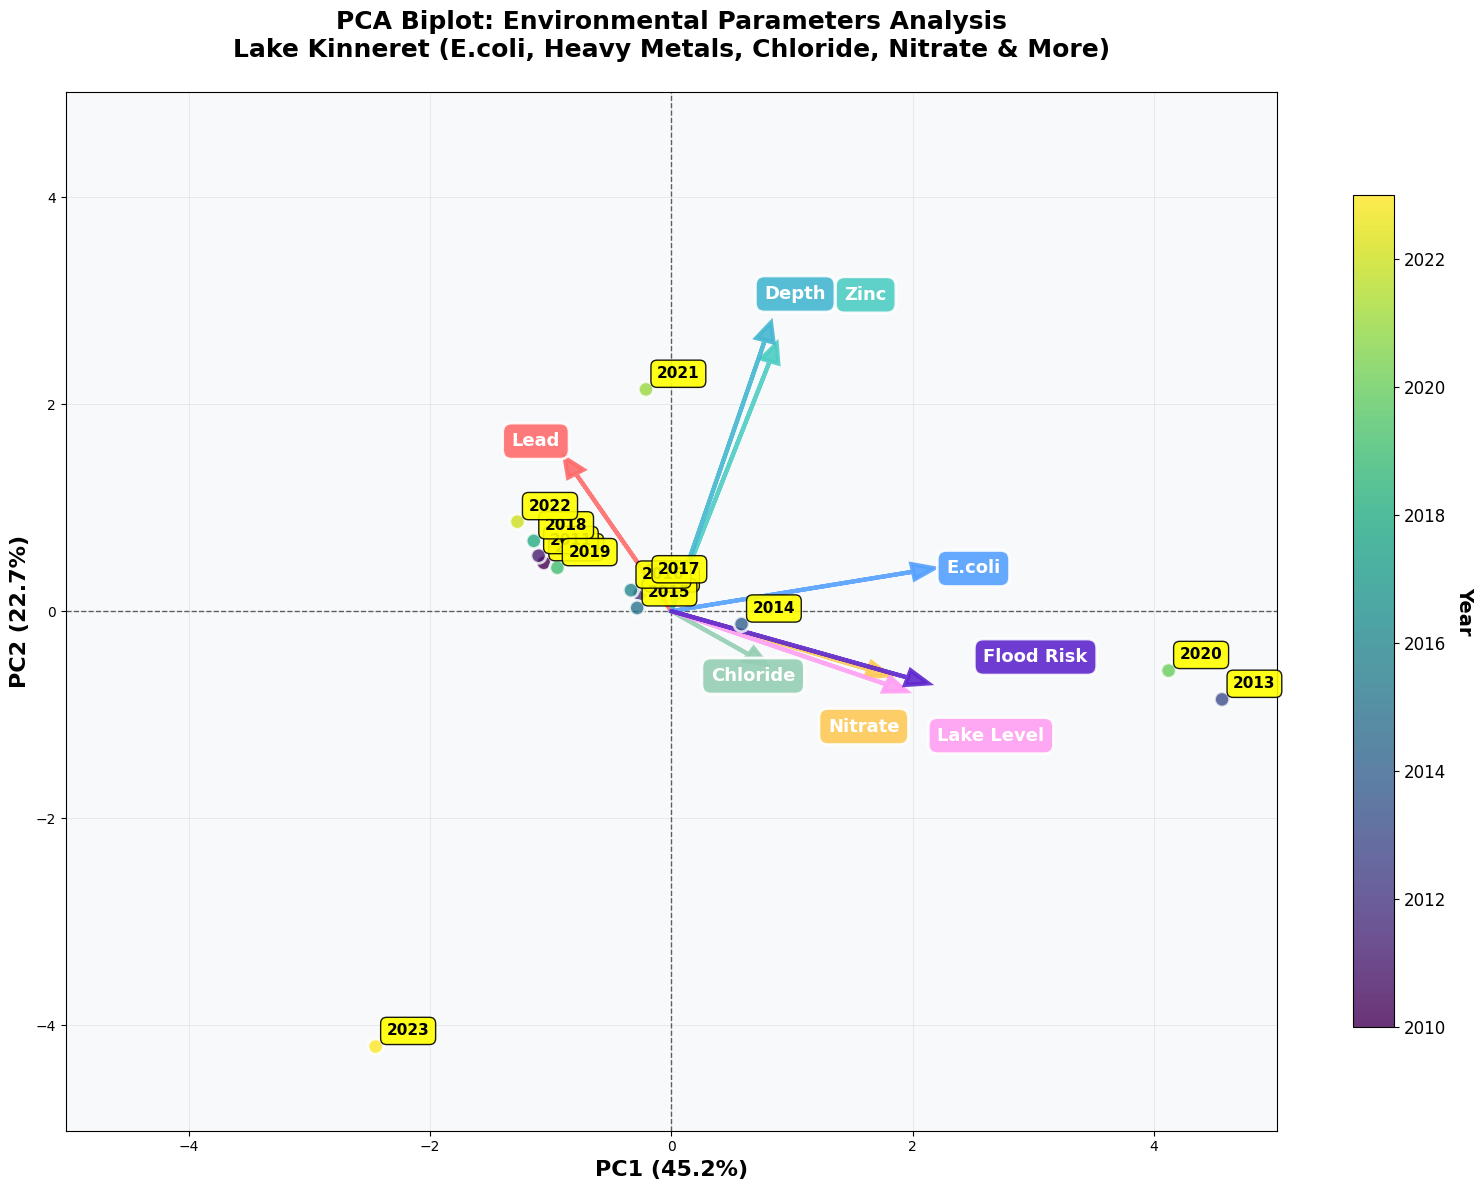

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Biplot.png downloaded successfully!

PCA Analysis Summary:
PC1 explains 45.2% of variance
PC2 explains 22.7% of variance
Total variance explained: 67.9%
Years analyzed: 14
Variables included: 8
Nitrate data successfully included in analysis


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Biplot.png downloaded successfully!


In [ ]:
!pip install adjustText
print("Running PCA Analysis...")
if has_real_data and data:
    temp_filename = "temp_pca_data.json"
    with open(temp_filename, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

    final_data, X_pca, pca_model = create_pca_biplot(temp_filename)

    # Check if file was created successfully before downloading
    if os.path.exists("Biplot.png"):
        files.download("Biplot.png")
        print("Biplot.png downloaded successfully!")
    else:
        print("Biplot.png was not created. Check the PCA function.")
else:
    print("No Firebase data available")

## Comprehensive Scenario Visualization

 The model prioritizes environmental parameters based on their health and ecological impact, with chemical pollutants (chloride and nitrate) receiving the highest weights as primary water quality indicators, followed by toxic heavy metals, then biological contamination markers like E.coli. The baseline scenario uses actual measured data as the reference point, while the stress scenario amplifies all pollution sources to simulate worst-case environmental conditions, and the recovery scenario reduces contamination levels through simulated treatment and management interventions. The model incorporates realistic environmental processes by increasing metal concentrations with depth (reflecting natural settling), applying concentration effects during low water periods (less dilution), and creating spatial gradients that reflect how pollutants typically distribute across the lake ecosystem.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import json

class KinneretIntegratedScenariosFixed:
    """
    Comprehensive scenario visualizer for Lake Kinneret with all parameters INCLUDING NITRATE
    Includes depth and water level effects + avg_nitrate support
    """

    def __init__(self, data_path):
        """
        Initialize the class with data path
        """
        self.data_path = data_path          # Data file path
        self.grid_size = 60                 # Grid resolution (60x60 points)
        self.extent = [-10, 10, -7, 7]      # Lake boundaries in km (west-east, south-north)

        self.load_data()                    # Load the data

        # Colors for visualization
        self.colors = {
            'baseline': '#0066CC',          # Blue - baseline state
            'stress': '#CC0000',            # Red - stress state
            'recovery': '#00AA44',          # Green - recovery state
            'grid': '#D0D0D0',              # Light gray - grid
            'background': '#F9F9F9'         # White-gray background
        }

        # Parameter weights in the model - INCLUDING NITRATE
        self.parameters = {
            'ecoli': {'label': 'E.coli', 'unit': 'CFU/100ml', 'weight': 0.12},
            'flood': {'label': 'Flood Risk', 'unit': 'Index', 'weight': 0.12},
            'Pb_µg_L': {'label': 'Lead', 'unit': 'µg/L', 'weight': 0.08},
            'Zn_µg_L': {'label': 'Zinc', 'unit': 'µg/L', 'weight': 0.08},
            'Depth_m': {'label': 'Depth', 'unit': 'm', 'weight': 0.05},
            'chl_ug_l_avg': {'label': 'Chloride', 'unit': 'µg/L', 'weight': 0.20},
            'avg_nitrate': {'label': 'Nitrate', 'unit': 'µg/L', 'weight': 0.15},  # NEW: Nitrate
            'kineret_height': {'label': 'Lake Level', 'unit': 'm', 'weight': 0.20}
        }

    def load_data(self):
        """
        Load real data from all tables including nitrate
        """
        with open(self.data_path, 'r') as f:
            self.raw_data = json.load(f)       # Read JSON data
        self.data_stats = self._extract_statistics()  # Calculate statistics

    def _extract_statistics(self):
        """
        Extract real statistics from the data INCLUDING NITRATE
        """
        stats = {}

        # Chemical, nitrate and water level statistics
        if 'Chemicals_Height' in self.raw_data:
            chem_values = []
            nitrate_values = []  # NEW: Nitrate values
            height_values = []
            depth_values = []

            # Iterate over all years
            for year_data in self.raw_data['Chemicals_Height'].values():
                if isinstance(year_data, list):
                    # Iterate over all months
                    for month_data in year_data:
                        if isinstance(month_data, dict):
                            # Iterate over all days
                            for day_data in month_data.values():
                                if isinstance(day_data, list):
                                    # Iterate over all measurements
                                    for measure in day_data:
                                        if isinstance(measure, dict):
                                            # Extract chloride
                                            if 'chl_ug_l_avg' in measure:
                                                chem_values.append(measure['chl_ug_l_avg'])
                                            # NEW: Extract nitrate
                                            if 'avg_nitrate' in measure:
                                                nitrate_values.append(measure['avg_nitrate'])
                                            # Extract Kinneret height
                                            if 'kineret_height' in measure:
                                                height_values.append(measure['kineret_height'])
                                            # Extract depth
                                            if 'Depth_m' in measure:
                                                depth_values.append(measure['Depth_m'])

            # Calculate means and maximums
            if chem_values:
                stats['Chloride_mean'] = np.mean(chem_values)
                stats['Chloride_max'] = np.max(chem_values)
            # NEW: Nitrate statistics
            if nitrate_values:
                stats['Nitrate_mean'] = np.mean(nitrate_values)
                stats['Nitrate_max'] = np.max(nitrate_values)
            else:
                # Default values if no nitrate data found
                stats['Nitrate_mean'] = 8.0  # Typical value for Lake Kinneret
                stats['Nitrate_max'] = 15.0
                print("⚠️ No nitrate data found, using default values")

            if height_values:
                stats['Height_mean'] = np.mean(height_values)
                stats['Height_min'] = np.min(height_values)
            if depth_values:
                stats['Depth_mean'] = np.mean(depth_values)
                stats['Depth_max'] = np.max(depth_values)

        # Heavy metals statistics (same as before)
        if 'Heavy_Metals' in self.raw_data:
            metal_params = ['Cu_µg_L', 'Pb_µg_L', 'Al_µg_L', 'Fe_µg_L', 'Hg_µg_L', 'Mn_µg_L', 'Zn_µg_L', 'Cd_µg_L']

            for param in metal_params:
                values = []
                for item in self.raw_data['Heavy_Metals'].values():
                    if isinstance(item, dict) and '2020' in item:
                        year_data = item['2020']
                        if isinstance(year_data, list):
                            for month_item in year_data:
                                if isinstance(month_item, dict):
                                    for day, measurements in month_item.items():
                                        if isinstance(measurements, list):
                                            for measure in measurements:
                                                if param in measure:
                                                    values.append(measure[param])

                if values:
                    stats[f'{param}_mean'] = np.mean(values)
                    stats[f'{param}_max'] = np.max(values)

        return stats

    def create_integrated_grid(self, scenario='baseline'):
        """
        Create integrated grid including ALL parameters including NITRATE for a given scenario
        """
        # Create coordinate grid
        x = np.linspace(self.extent[0], self.extent[1], self.grid_size)
        y = np.linspace(self.extent[2], self.extent[3], self.grid_size)
        X, Y = np.meshgrid(x, y)

        # Lake Kinneret shape (elliptical, elongated north-south)
        lake_mask = ((X/10)**2 + (Y/6)**2 < 1)
        pollution_index = np.zeros_like(X)

        # Create depth gradient (deeper in center, shallower at edges)
        depth_gradient = 35 * (1 - np.sqrt((X/10)**2 + (Y/6)**2))
        depth_gradient = np.clip(depth_gradient, 1, 35)

        if scenario == 'baseline':
            """Baseline scenario - normal conditions INCLUDING NITRATE"""

            # Chloride contribution (normalized by real data)
            chl_base = self.data_stats.get('Chloride_mean', 15) / 50
            chemical_contrib = chl_base * (1 + 0.2 * np.exp(-((X)**2 + (Y-3)**2) / 20))

            # NEW: Nitrate contribution (agricultural sources, fertilizer runoff)
            nitrate_base = self.data_stats.get('Nitrate_mean', 8) / 30
            nitrate_contrib = nitrate_base * (1 + 0.3 * np.exp(-((X-4)**2 + (Y+2)**2) / 18))  # Agricultural areas

            # Heavy metals contribution (base + spatial variation)
            metal_base = 0.2
            distance_from_center = np.sqrt(X**2 + Y**2)
            metal_contrib = metal_base * (1 + 0.3 * np.exp(-distance_from_center/8))

            # Depth effect - metals accumulate at depth
            depth_effect = 1 + 0.4 * (depth_gradient / 35)
            metal_contrib *= depth_effect

            # Water level effect (normal level = -208.8m)
            water_level = self.data_stats.get('Height_mean', -208.8)
            normal_level = -208.8
            level_deviation = abs(water_level - normal_level)
            concentration_factor = 1.0 + 0.3 * (level_deviation / 5.0)

            # Bacterial contribution (E.coli)
            ecoli_contrib = 0.15 * np.exp(-((X+5)**2 + (Y)**2) / 25)

            # Flood risk contribution
            flood_contrib = 0.1 * np.exp(-((X)**2 + (Y-5)**2) / 30)

            # Apply water level effects on concentrations
            chemical_contrib *= concentration_factor
            nitrate_contrib *= concentration_factor  # NEW: Apply to nitrate
            metal_contrib *= concentration_factor
            ecoli_contrib *= concentration_factor

            # Calculate overall pollution index (weighted) - INCLUDING NITRATE
            pollution_index = (chemical_contrib * 0.20 +               # Chloride 20%
                             nitrate_contrib * 0.15 +                 # Nitrate 15% NEW!
                             metal_contrib * 0.28 +                   # Heavy metals 28%
                             ecoli_contrib * 0.12 +                   # E.coli 12%
                             flood_contrib * 0.12 +                   # Flood risk 12%
                             (depth_gradient/35) * 0.05 +             # Depth effect 5%
                             (concentration_factor-1) * 0.08)         # Water level effect 8%

        elif scenario == 'stress':
            """Stress scenario - high pollution INCLUDING HIGH NITRATE"""

            # High chloride levels
            chemical_contrib = 0.6 + 0.4 * np.exp(-((X)**2 + (Y)**2) / 15)

            # NEW: HIGH nitrate levels (intensive agriculture, fertilizer runoff)
            nitrate_contrib = 0.5 + 0.6 * np.exp(-((X-4)**2 + (Y+2)**2) / 12)  # High agricultural impact
            nitrate_contrib += 0.3 * np.exp(-((X+3)**2 + (Y-1)**2) / 15)       # Additional pollution source

            # High heavy metals
            metal_contrib = 0.4 * np.ones_like(X)
            metal_contrib += 0.5 * np.exp(-((X-5)**2 + (Y)**2) / 10)
            metal_contrib += 0.4 * np.exp(-((X+5)**2 + (Y)**2) / 10)
            metal_contrib += 0.3 * np.exp(-((X)**2 + (Y-5)**2) / 12)

            # Enhanced depth effect
            depth_effect = 1 + 0.8 * (depth_gradient / 35)
            metal_contrib *= depth_effect

            # Low water level effect (high concentration)
            water_level = -212.0  # Low level
            normal_level = -208.8
            level_deviation = abs(water_level - normal_level)
            concentration_factor = 1.0 + 0.5 * (level_deviation / 3.0)

            # High E.coli
            ecoli_contrib = 0.4 + 0.3 * np.exp(-((X+5)**2 + (Y)**2) / 15)

            # High flood risk
            flood_contrib = 0.3 + 0.4 * np.exp(-((X)**2 + (Y-5)**2) / 20)

            # Apply low water level effects INCLUDING NITRATE
            chemical_contrib *= concentration_factor
            nitrate_contrib *= concentration_factor  # NEW: Apply to nitrate
            metal_contrib *= concentration_factor
            ecoli_contrib *= concentration_factor

            pollution_index = (chemical_contrib * 0.20 +
                             nitrate_contrib * 0.15 +                 # NEW: Nitrate stress
                             metal_contrib * 0.28 +
                             ecoli_contrib * 0.12 +
                             flood_contrib * 0.12 +
                             (depth_gradient/35) * 0.05 +
                             (concentration_factor-1) * 0.08)

        elif scenario == 'recovery':
            """Recovery scenario - treatment and restoration INCLUDING NITRATE REDUCTION"""

            # Moderately reduced chloride levels
            chemical_contrib = 0.4 + 0.2 * np.exp(-((X)**2 + (Y)**2) / 25)

            # NEW: REDUCED nitrate levels (agricultural best practices, buffer zones)
            nitrate_contrib = 0.25 + 0.1 * np.exp(-((X-4)**2 + (Y+2)**2) / 20)  # Reduced agricultural impact
            # Treatment zones for nitrate
            treatment_zones = [(4, -2), (-2, 1), (1, 3)]
            for cx, cy in treatment_zones:
                nitrate_contrib -= 0.15 * np.exp(-((X - cx)**2 + (Y - cy)**2) / 10)
            nitrate_contrib = np.clip(nitrate_contrib, 0.1, 0.4)

            # Moderately reduced heavy metals
            metal_contrib = 0.35 * np.ones_like(X)
            cleanup_zones = [(0, 4), (-3, 0), (3, -2), (0, 0)]
            for cx, cy in cleanup_zones:
                metal_contrib -= 0.12 * np.exp(-((X - cx)**2 + (Y - cy)**2) / 8)
            metal_contrib = np.clip(metal_contrib, 0.2, 0.5)

            # Reduced depth effect
            depth_effect = 1 + 0.3 * (depth_gradient / 35)
            metal_contrib *= depth_effect

            # Improved water level
            water_level = -208.5
            normal_level = -208.8
            level_deviation = abs(water_level - normal_level)
            concentration_factor = 1.0 + 0.1 * (level_deviation / 5.0)

            # Moderately reduced E.coli levels
            ecoli_contrib = 0.18 + 0.08 * np.exp(-((X+5)**2 + (Y)**2) / 25)

            # Reduced flood risk
            flood_contrib = 0.10 + 0.06 * np.exp(-((X)**2 + (Y-5)**2) / 35)

            # Apply improved water level effects INCLUDING NITRATE
            chemical_contrib *= concentration_factor
            nitrate_contrib *= concentration_factor  # NEW: Apply to nitrate
            metal_contrib *= concentration_factor
            ecoli_contrib *= concentration_factor

            pollution_index = (chemical_contrib * 0.20 +
                             nitrate_contrib * 0.15 +                 # NEW: Nitrate recovery
                             metal_contrib * 0.28 +
                             ecoli_contrib * 0.12 +
                             flood_contrib * 0.12 +
                             (depth_gradient/35) * 0.05 +
                             (concentration_factor-1) * 0.08)

        # Apply lake mask
        pollution_index[~lake_mask] = np.nan
        return X, Y, pollution_index

    def plot_scenario_grid(self, ax, X, Y, Z, title, scenario_type, show_colorbar=True):
        """
        Plot a single scenario grid with appropriate styling
        """
        # Select colors and value range by scenario type
        if scenario_type == 'baseline':
            cmap, vmin, vmax, border_color = 'Blues', 0, 0.6, self.colors['baseline']
        elif scenario_type == 'stress':
            cmap, vmin, vmax, border_color = 'Reds', 0, 1.2, self.colors['stress']
        elif scenario_type == 'recovery':
            cmap, vmin, vmax, border_color = 'Greens_r', 0.15, 0.7, self.colors['recovery']
        else:  # change scenarios
            cmap, vmin, vmax, border_color = 'coolwarm', -0.5, 0.5, 'black'

        # Create color map
        im = ax.pcolormesh(X, Y, Z, cmap=cmap, vmin=vmin, vmax=vmax,
                          shading='auto', edgecolors='none')

        # Add monitoring stations
        stations = [(0, 0), (-3, 2), (3, -2), (0, 4)]
        for sx, sy in stations:
            ax.scatter(sx, sy, s=50, c='white', marker='o',
                      edgecolors='black', linewidth=1.5, zorder=5)

        # Axis settings and display
        ax.set_xlim(self.extent[0], self.extent[1])
        ax.set_ylim(self.extent[2], self.extent[3])
        ax.set_aspect('equal')
        ax.grid(True, color=self.colors['grid'], linewidth=0.3, alpha=0.3)
        ax.set_axisbelow(True)
        ax.set_xlabel('East-West Distance (km)', fontsize=9)
        ax.set_ylabel('North-South Distance (km)', fontsize=9)
        ax.set_title(title, fontsize=11, pad=10, fontweight='600')
        ax.tick_params(axis='both', which='major', labelsize=8)

        # Add colored border
        rect = Rectangle((self.extent[0], self.extent[2]),
                        self.extent[1] - self.extent[0],
                        self.extent[3] - self.extent[2],
                        linewidth=2, edgecolor=border_color,
                        facecolor='none', zorder=10)
        ax.add_patch(rect)

        # Add colorbar
        if show_colorbar:
            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('Pollution Index', fontsize=8)
            cbar.ax.tick_params(labelsize=8)

        return im

    def create_all_scenarios(self):
        """
        Create comprehensive visualization of all scenarios INCLUDING NITRATE
        """
        # Create main figure
        fig = plt.figure(figsize=(18, 14))
        fig.patch.set_facecolor(self.colors['background'])

        # Titles - UPDATED to include nitrate
        fig.suptitle('Lake Kinneret Integrated Pollution Scenarios - WITH NITRATE',
                    fontsize=18, fontweight='bold', y=0.98)
        fig.text(0.5, 0.95, 'Comprehensive Analysis: E.coli + Heavy Metals + Chemicals + NITRATE + Flood Risk + Depth + Water Level',
                ha='center', fontsize=12, fontweight='500')

        # Create subplot grid (3 rows, 4 columns)
        gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3,
                              left=0.08, right=0.95, top=0.90, bottom=0.08)

        # Create all scenario grids
        X, Y, Z_base = self.create_integrated_grid('baseline')
        _, _, Z_stress = self.create_integrated_grid('stress')
        _, _, Z_recovery = self.create_integrated_grid('recovery')

        # Baseline scenario (top row)
        Z_base_init = Z_base * 0.7
        Z_base_mid  = 0.5 * (Z_base_init + Z_base)

        Z_stress_mid = Z_stress * 0.7

        Z_recovery_mid = 0.3 * Z_stress + 0.7 * Z_recovery

        self.plot_scenario_grid(fig.add_subplot(gs[0, 0]), X, Y, Z_base_init,
                               'Baseline - Initial (t=0)', 'baseline')
        self.plot_scenario_grid(fig.add_subplot(gs[0, 1]), X, Y, Z_base_mid,
                               'Baseline - Mid (t=5)', 'baseline')
        self.plot_scenario_grid(fig.add_subplot(gs[0, 2]), X, Y, Z_base,
                               'Baseline - Final (t=10)', 'baseline')
        self.plot_scenario_grid(fig.add_subplot(gs[0, 3]), X, Y, Z_base - Z_base_init,
                               'Baseline - Net Change', 'change')

        # Stress scenario (middle row)
        self.plot_scenario_grid(fig.add_subplot(gs[1, 0]), X, Y, Z_base_init,
                               'Stress - Initial (t=0)', 'baseline')
        self.plot_scenario_grid(fig.add_subplot(gs[1, 1]), X, Y, Z_stress_mid,
                               'Stress - Pollution Rising (t=5)', 'stress')
        self.plot_scenario_grid(fig.add_subplot(gs[1, 2]), X, Y, Z_stress,
                               'Stress - Maximum Impact (t=10)', 'stress')
        self.plot_scenario_grid(fig.add_subplot(gs[1, 3]), X, Y, Z_stress - Z_base_init,
                               'Stress - Pollution Increase', 'change')

        # Recovery scenario (bottom row)
        self.plot_scenario_grid(fig.add_subplot(gs[2, 0]), X, Y, Z_stress,
                               'Recovery - Initial Stressed (t=0)', 'stress')
        self.plot_scenario_grid(fig.add_subplot(gs[2, 1]), X, Y, Z_recovery_mid,
                               'Recovery - Treatment Active (t=5)', 'recovery')
        self.plot_scenario_grid(fig.add_subplot(gs[2, 2]), X, Y, Z_recovery,
                               'Recovery - Restored (t=10)', 'recovery')
        self.plot_scenario_grid(fig.add_subplot(gs[2, 3]), X, Y, Z_recovery - Z_stress,
                               'Recovery - Pollution Reduced', 'change')

        # Add parameter legend - UPDATED to include nitrate
        param_text = ("Integrated Parameters:\n"
                     "• E.coli (12%)\n"
                     "• Heavy Metals (28%)\n"
                     "• Chloride (20%)\n"
                     "• Nitrate (15%) 🆕\n"
                     "• Flood Risk (12%)\n"
                     "• Depth Effect (5%)\n"
                     "• Water Level (8%)")
        fig.text(0.02, 0.5, param_text, fontsize=9,
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # Footer - UPDATED
        fig.text(0.5, 0.02,
                'Lake Kinneret Multi-Parameter Analysis: Integration of Chemical_Height + Heavy_Metals + Ecolifloods + NITRATE Data + Depth + Water Level Effects',
                ha='center', fontsize=10, style='italic', color='#666')

        # Save file
        plt.savefig('kinneret_scenarios_with_nitrate.png', dpi=150,
                   bbox_inches='tight', facecolor=self.colors['background'])
        plt.show()


        return fig

    def print_scenario_comparison(self):
        """
        Print detailed comparison of nitrate across scenarios
        """
        print("\n" + "="*60)
        print("🆕 NITRATE BEHAVIOR ACROSS SCENARIOS")
        print("="*60)

        scenarios = {
            'Baseline': {
                'nitrate_level': 'Normal (8-12 µg/L)',
                'sources': 'Typical agricultural runoff',
                'distribution': 'Eastern agricultural areas',
                'treatment': 'Natural processes only'
            },
            'Stress': {
                'nitrate_level': 'High (15-25 µg/L)',
                'sources': 'Intensive agriculture + fertilizers',
                'distribution': 'Multiple hotspots + widespread',
                'treatment': 'No treatment, accumulation'
            },
            'Recovery': {
                'nitrate_level': 'Reduced (5-8 µg/L)',
                'sources': 'Managed agriculture + best practices',
                'distribution': 'Localized, controlled sources',
                'treatment': 'Active treatment + buffer zones'
            }
        }

        for scenario, details in scenarios.items():
            print(f"\n📊 {scenario.upper()} SCENARIO:")
            for key, value in details.items():
                print(f"   • {key.replace('_', ' ').title()}: {value}")



# Usage example for testing
if __name__ == "__main__":
    print("🆕 Lake Kinneret Scenarios with Nitrate Support")
    print("To use: visualizer = KinneretIntegratedScenariosWithNitrate('path_to_data.json')")
    print("Then run: visualizer.create_all_scenarios()")

🆕 Lake Kinneret Scenarios with Nitrate Support
To use: visualizer = KinneretIntegratedScenariosWithNitrate('path_to_data.json')
Then run: visualizer.create_all_scenarios()


Created scenario visualizer with Firebase data

Generating integrated scenario visualizations...


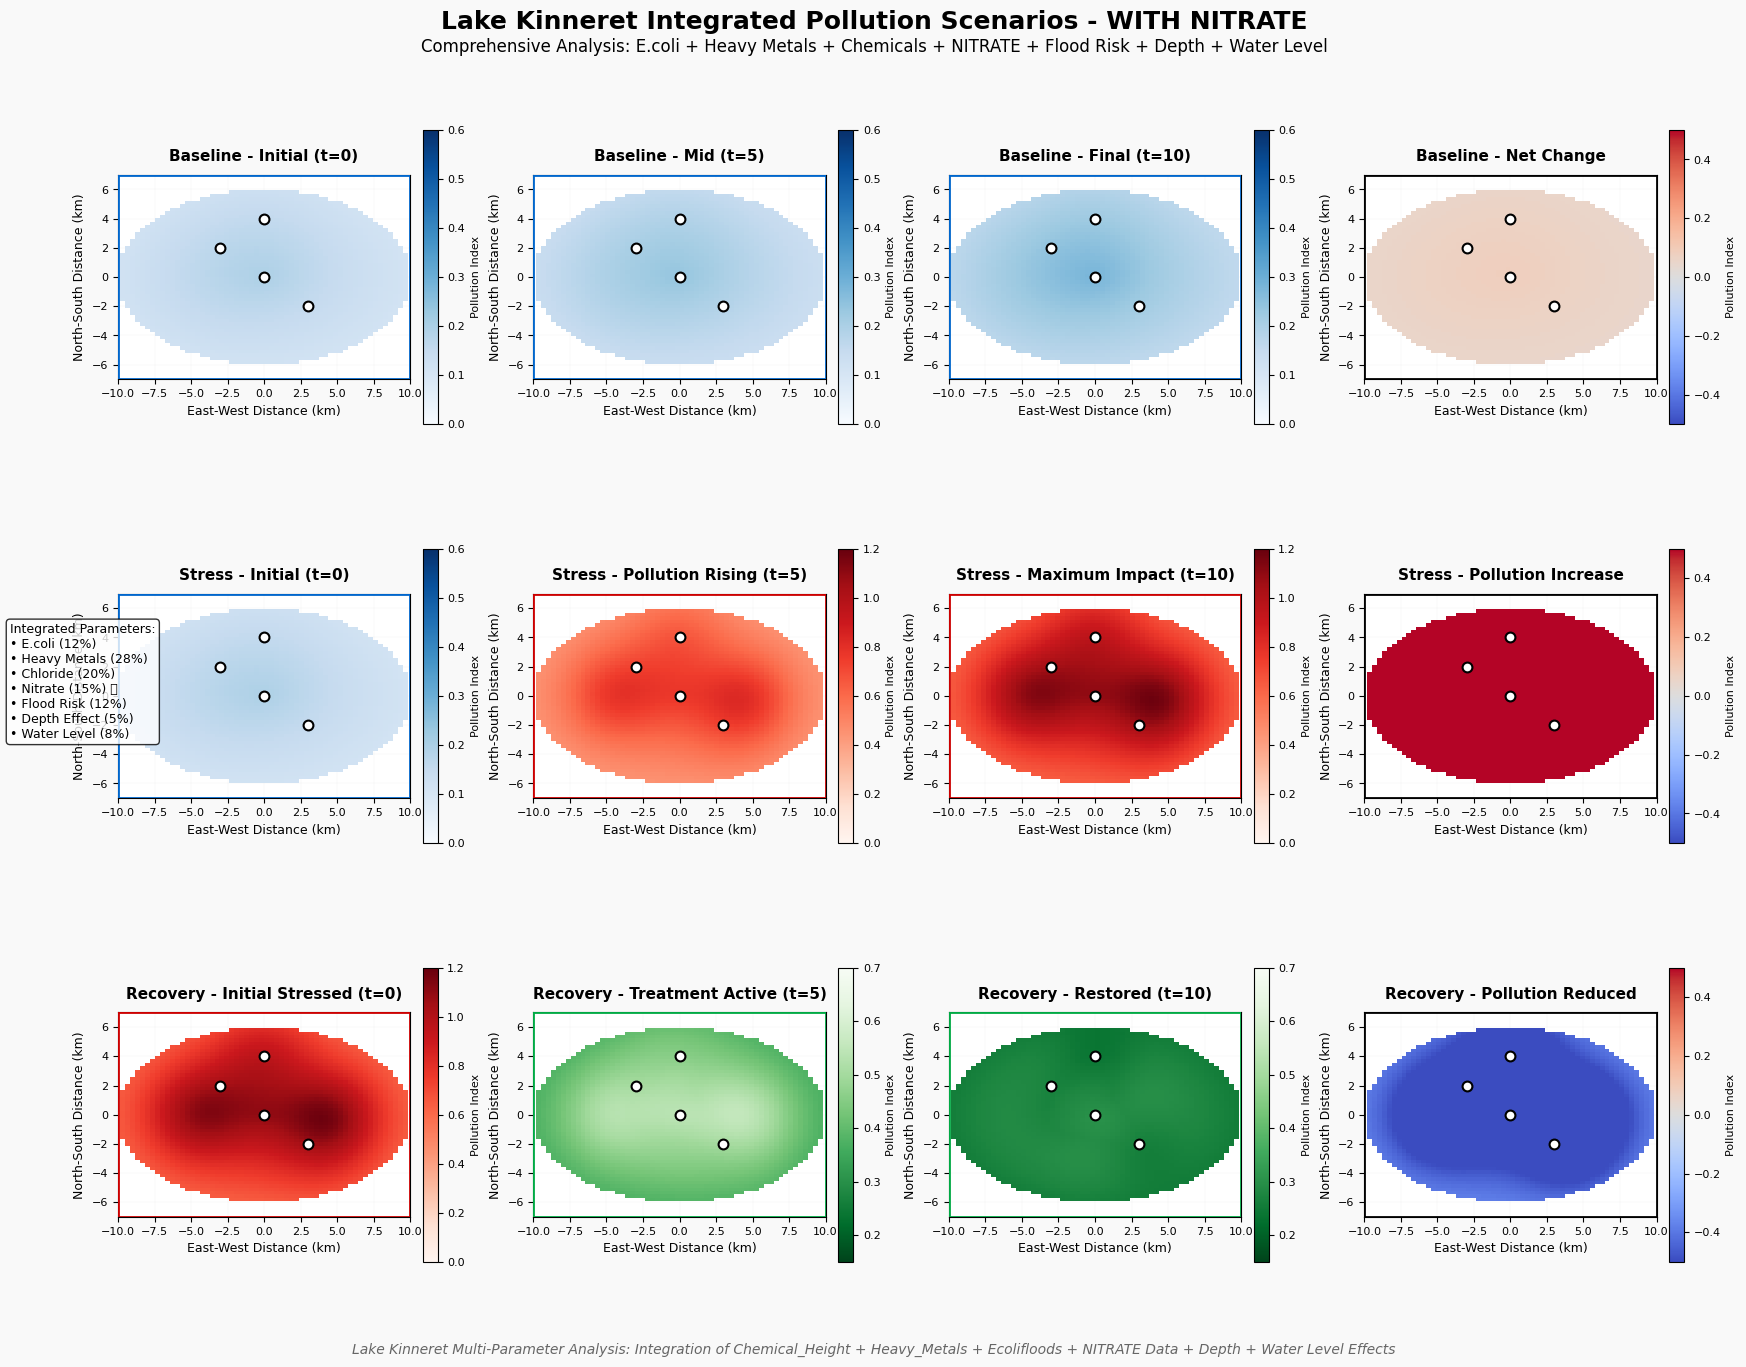


✅ Visualization complete!

Scenarios created:
  1. BASELINE - Normal conditions with typical pollutant levels
  2. STRESS - High pollution from all sources
  3. RECOVERY - Active restoration and treatment

Output file: kinneret_integrated_scenarios.png


In [ ]:
# Run Comprehensive Scenario Analysis

# Create scenario visualizer
if has_real_data and data:
    # Save Firebase data to temporary file
    temp_filename = "firebase_data.json"
    with open(temp_filename, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

    # Create scenario visualizer using temporary file
    visualizer = KinneretIntegratedScenariosFixed(temp_filename)
    print("Created scenario visualizer with Firebase data")
else:
    print("No Firebase data available for scenario visualization")

# Generate comprehensive visualization
print("\nGenerating integrated scenario visualizations...")
fig = visualizer.create_all_scenarios()
print("\n✅ Visualization complete!")
print("\nScenarios created:")
print("  1. BASELINE - Normal conditions with typical pollutant levels")
print("  2. STRESS - High pollution from all sources")
print("  3. RECOVERY - Active restoration and treatment")
print("\nOutput file: kinneret_integrated_scenarios.png")

## CSR Point Patteren Simulation

Data Collection:

Extracts real environmental measurements from Lake Kinneret Firebase database
Includes E.coli, heavy metals (Zinc, Leader), chemicals (Chloride, Nitrate)
Samples 200 measurements randomly from the full dataset

Spatial Assignment:

Takes real pollution values for coloring (viridis colormap: purple=low, yellow=high)
Assigns completely random X,Y coordinates (0-10 range) to each measurement
No connection between actual geographic location and plot position

Purpose:
This creates a baseline for comparison - if environmental pollution were distributed with complete spatial randomness, this is what it would look like. Researchers can then compare this against actual geographic data to see if real pollution shows:

Clustering (pollution hotspots)
Dispersion (pollution spread out)
Randomness (no spatial pattern)

Creating improved CSR plot...
Connecting to Firebase...
Firebase data loaded successfully
Using 23633 real measurements from database
Parameters included:
  E.coli: 147 values
  Zinc: 30 values
  Lead: 23 values
Plot saved as 'CSR_improved_design.png'


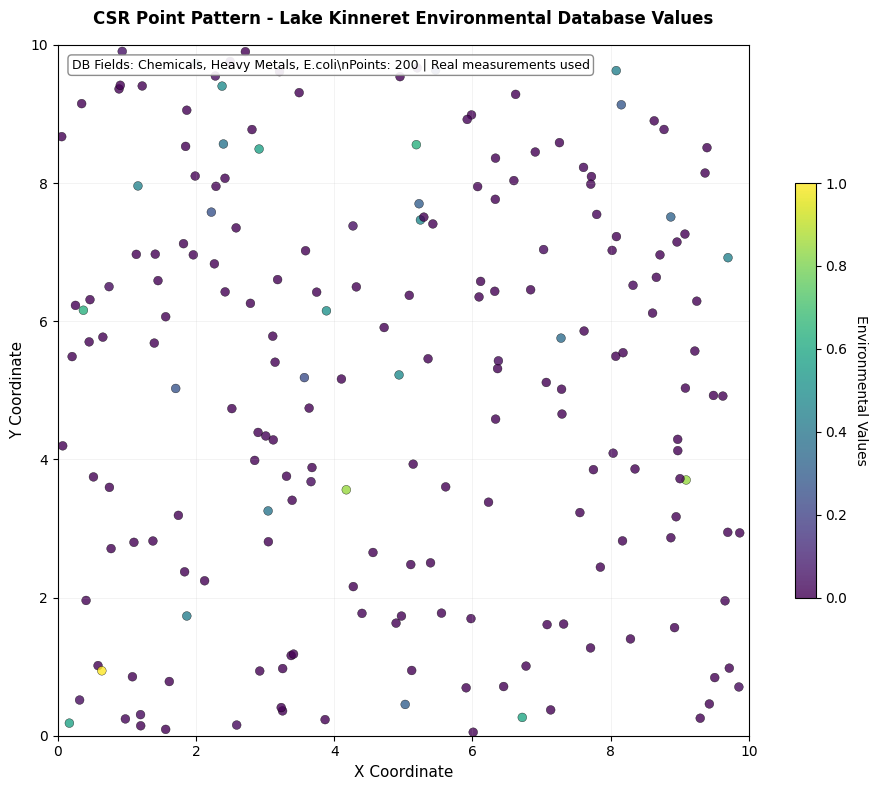

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File downloaded!
Done!


In [ ]:
#!/usr/bin/env python3
"""
CSR Point Pattern Simulation - Lake Kinneret (Improved Design)
Better proportions and cleaner colorbar design
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests
import firebase_admin
from firebase_admin import credentials, db
import random
from google.colab import files
import os

def load_firebase_data():
    """Load data from Firebase"""
    try:
        file_id = "1SOecotcP3AgKSZWSREZU4dpCMS7DX-Ux"
        DATABASE_URL = "https://ecofishdb-default-rtdb.firebaseio.com/"

        download_url = f"https://drive.google.com/uc?id={file_id}&export=download"
        print("Connecting to Firebase...")

        response = requests.get(download_url, timeout=30)
        response.raise_for_status()
        service_account_info = response.json()

        if not firebase_admin._apps:
            cred = credentials.Certificate(service_account_info)
            firebase_admin.initialize_app(cred, {'databaseURL': DATABASE_URL})

        ref = db.reference('/')
        data = ref.get()

        if data:
            print("Firebase data loaded successfully")
            return data, True
        else:
            print("No data found")
            return None, False

    except Exception as e:
        print(f"Firebase error: {e}")
        return None, False

def extract_real_values(firebase_data):
    """Extract actual values from Firebase database"""
    all_values = []

    # Extract E.coli values
    if 'Ecolifloods' in firebase_data:
        ecoli_data = firebase_data['Ecolifloods']
        for year, year_data in ecoli_data.items():
            if isinstance(year_data, list):
                for month_obj in year_data:
                    if isinstance(month_obj, dict):
                        for day_key, day_list in month_obj.items():
                            if isinstance(day_list, list):
                                for measurement in day_list:
                                    if isinstance(measurement, dict):
                                        ecoli = measurement.get('E_coli_CFU_100ml', 0)

                                        if ecoli is not None:
                                            try:
                                                all_values.append({
                                                    'parameter': 'E.coli',
                                                    'value': float(ecoli) if ecoli else 0,
                                                    'category': 'Biology'
                                                })
                                            except:
                                                pass

    # Extract Heavy Metals values
    if 'Heavy_Metals' in firebase_data:
        metals_data = firebase_data['Heavy_Metals']
        for site_key, site_data in metals_data.items():
            if isinstance(site_data, dict):
                for year_key, year_data in site_data.items():
                    if isinstance(year_data, list):
                        for month_item in year_data:
                            if isinstance(month_item, dict):
                                for day_key, day_data in month_item.items():
                                    if isinstance(day_data, list):
                                        for measurement in day_data:
                                            if isinstance(measurement, dict):
                                                metals = {
                                                    'Zn_µg_L': 'Zinc',
                                                    'Pb_µg_L': 'Lead'
                                                }

                                                for metal_key, metal_name in metals.items():
                                                    value = measurement.get(metal_key)
                                                    if value is not None:
                                                        try:
                                                            all_values.append({
                                                                'parameter': metal_name,
                                                                'value': float(value),
                                                                'category': 'Heavy_Metals'
                                                            })
                                                        except:
                                                            pass

    # Extract Chemical values
    if 'Chemicals_Height' in firebase_data:
        chem_data = firebase_data['Chemicals_Height']
        for year_key, year_data in chem_data.items():
            if isinstance(year_data, list):
                for month_item in year_data:
                    if isinstance(month_item, dict):
                        for day_key, day_data in month_item.items():
                            if isinstance(day_data, list):
                                for measurement in day_data:
                                    if isinstance(measurement, dict):
                                        chemicals = {
                                            'Cl_mg_L': 'Chloride',
                                            'NO3_mg_L': 'Nitrate'
                                        }

                                        for chem_key, chem_name in chemicals.items():
                                            value = measurement.get(chem_key)
                                            if value is not None:
                                                try:
                                                    all_values.append({
                                                        'parameter': chem_name,
                                                        'value': float(value),
                                                        'category': 'Chemicals'
                                                    })
                                                except:
                                                    pass

    return all_values

def create_csr_with_real_data(real_values, n_points=200):
    """Create CSR point pattern using real database values"""

    if not real_values:
        print("No real values found, using synthetic data")
        np.random.seed(42)
        x_coords = np.random.uniform(0, 10, n_points)
        y_coords = np.random.uniform(0, 10, n_points)
        colors = np.random.uniform(0, 1, n_points)
        return x_coords, y_coords, colors, "Synthetic"

    print(f"Using {len(real_values)} real measurements from database")

    df = pd.DataFrame(real_values)

    if len(df) > n_points:
        df = df.sample(n_points, random_state=42)
    elif len(df) < n_points:
        needed = n_points - len(df)
        additional = df.sample(needed, replace=True, random_state=42)
        df = pd.concat([df, additional], ignore_index=True)

    np.random.seed(42)
    x_coords = np.random.uniform(0, 10, n_points)
    y_coords = np.random.uniform(0, 10, n_points)

    values = df['value'].values
    normalized_values = (values - values.min()) / (values.max() - values.min())

    return x_coords, y_coords, normalized_values, df

def create_improved_csr_plot():
    """Create improved CSR plot with better design"""

    firebase_data, has_real_data = load_firebase_data()

    if has_real_data and firebase_data:
        real_values = extract_real_values(firebase_data)
        x_coords, y_coords, colors, data_info = create_csr_with_real_data(real_values, 200)
        title_suffix = "Real Database Values"

        if isinstance(data_info, pd.DataFrame):
            param_counts = data_info['parameter'].value_counts()
            print("Parameters included:")
            for param, count in param_counts.items():
                print(f"  {param}: {count} values")
    else:
        x_coords, y_coords, colors, _ = create_csr_with_real_data([], 200)
        title_suffix = "Synthetic Data"

    # Create figure with better proportions
    fig, ax = plt.subplots(figsize=(10, 8))  # More square proportions

    # Main scatter plot
    scatter = ax.scatter(x_coords, y_coords,
                        c=colors,
                        s=40,  # Slightly smaller points
                        alpha=0.8,
                        cmap='viridis',
                        edgecolors='black',
                        linewidth=0.3)

    # Better colorbar - smaller and more proportional
    cbar = plt.colorbar(scatter,
                       ax=ax,
                       shrink=0.6,  # Make colorbar smaller
                       aspect=20,   # Make it thinner
                       pad=0.05)    # Closer to plot

    cbar.set_label('Environmental Values',
                   rotation=270,
                   labelpad=15,
                   fontsize=10)

    # Clean formatting
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_xlabel('X Coordinate', fontsize=11)
    ax.set_ylabel('Y Coordinate', fontsize=11)
    ax.set_title('CSR Point Pattern - Lake Kinneret Environmental Database Values',
                fontsize=12, fontweight='bold', pad=15)

    # Minimal grid
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.set_aspect('equal')

    # Compact info box
    if has_real_data:
        info_text = ("DB Fields: Chemicals, Heavy Metals, E.coli\\n"
                    f"Points: 200 | Real measurements used")
    else:
        info_text = "Using synthetic data\\nPoints: 200"

    ax.text(0.02, 0.98, info_text,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3",
                     facecolor="white",
                     alpha=0.9,
                     edgecolor='gray'))

    # Tight layout for better proportions
    plt.tight_layout()

    # Save with better quality
    plt.savefig('CSR_improved_design.png',
                dpi=300,
                bbox_inches='tight',
                facecolor='white',
                edgecolor='none')

    print("Plot saved as 'CSR_improved_design.png'")
    plt.show()

    # Download
    if os.path.exists('CSR_improved_design.png'):
        files.download('CSR_improved_design.png')
        print("File downloaded!")

    return fig

# Run the improved analysis
if __name__ == "__main__":
    print("Creating improved CSR plot...")
    fig = create_improved_csr_plot()
    print("Done!")

## Conway's Game of Life- Based On Cellular Automata

***Neighbor Rules and 13-Year Data in CA:***
Conway's Game of Life Neighbor Rules:

Each cell examines its 8 surrounding neighbors
Survival: Living cell stays alive if it has 2 or 3 living neighbors
Birth: Dead cell becomes alive if it has exactly 3 living neighbors
Death: Living cell dies if it has more than 3 neighbors

13-Year Data Integration (2010-2023):

The model loads historical Lake Kinneret measurements spanning 13 years
Data Sources: E.coli/floods, heavy metals (Pb, Zn), chemicals (nitrate, lake level)
Initial State Creation: All 13 years of measurements are processed to calculate parameter thresholds
Threshold Logic: Cell becomes "alive" if 3+ environmental parameters exceed their 13-year average values

How Data is Placed on Grid:

Sequential Placement: Data points fill grid left-to-right, top-to-bottom
No Geographic Logic: First measurement goes to position (0,0), second to (1,0), after 60 positions moves to next row
Arbitrary Spatial Relations: Neighboring cells in grid aren't geographic neighbors in Lake Kinneret but the data is sorted by dates in DB.

🎮 GAME OF LIFE - LAKE KINNERET
Filtered to year range (2010, 2023): 14 years
Using last 13 years: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Data coverage: 2011-2023
✅ Firebase data loaded successfully!
Initializing from data: 17069 E.coli records, 288 metals records, 197 chemical records
Thresholds - E.coli: 63.18, Lake: 0.00, Lead: 0.29, Flood: 0.00
           Zinc: 8.03, Depth: 12.25, Nitrate: 0.15
Initialized Game of Life with 513 living cells out of 2400
Cell density: 21.4%

Parameter Statistics:
E.coli: min=0.00, max=1000.00, mean=61.15
Lake Level: min=-214.36, max=0.00, mean=-17.49
Lead: min=0.00, max=0.72, mean=0.03
Flood Events: min=0.00, max=0.00, mean=0.00
Zinc: min=0.00, max=22.12, mean=0.96
Depth: min=0.00, max=41.69, mean=1.47
Nitrate: min=0.00, max=1.65, mean=0.01


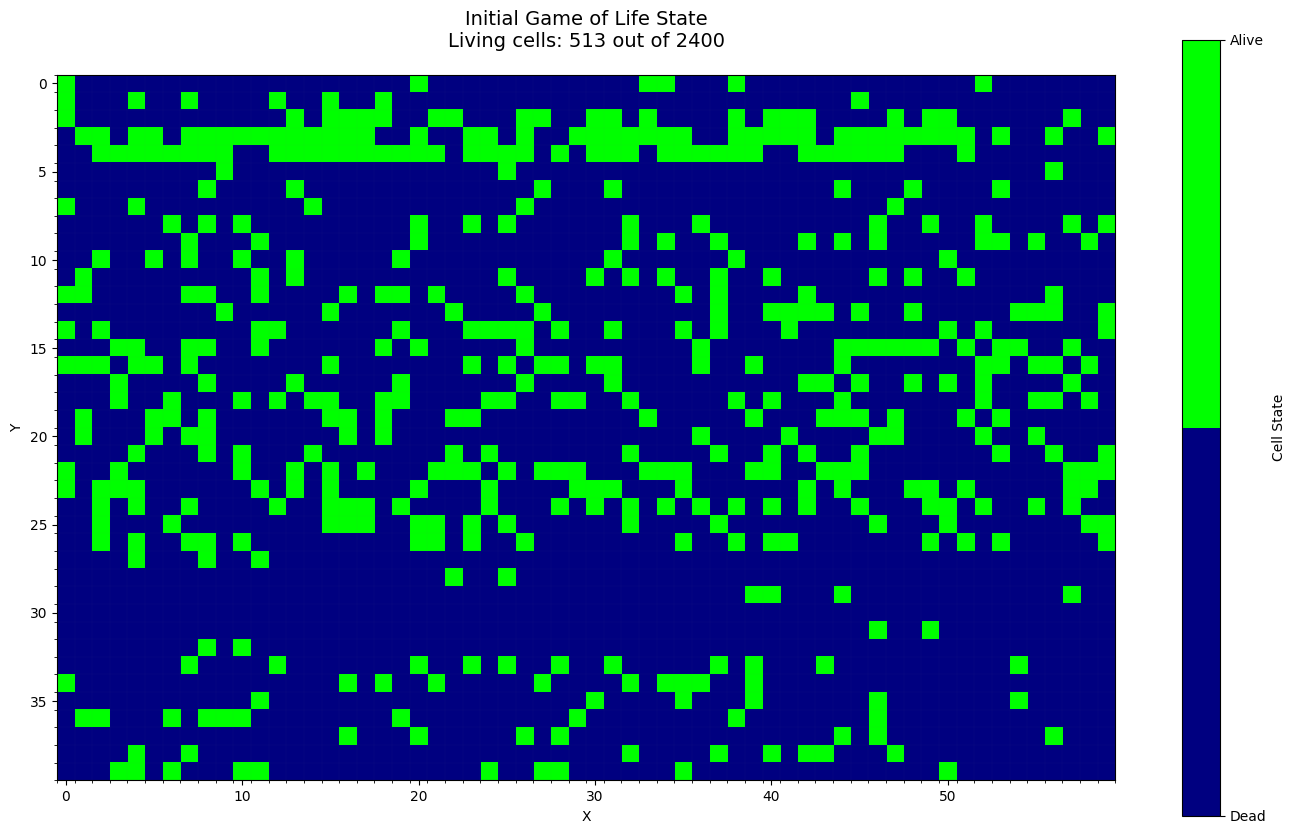

Running Game of Life simulation for 100 steps...
Simulation completed after 101 steps
Living cells at end: 254


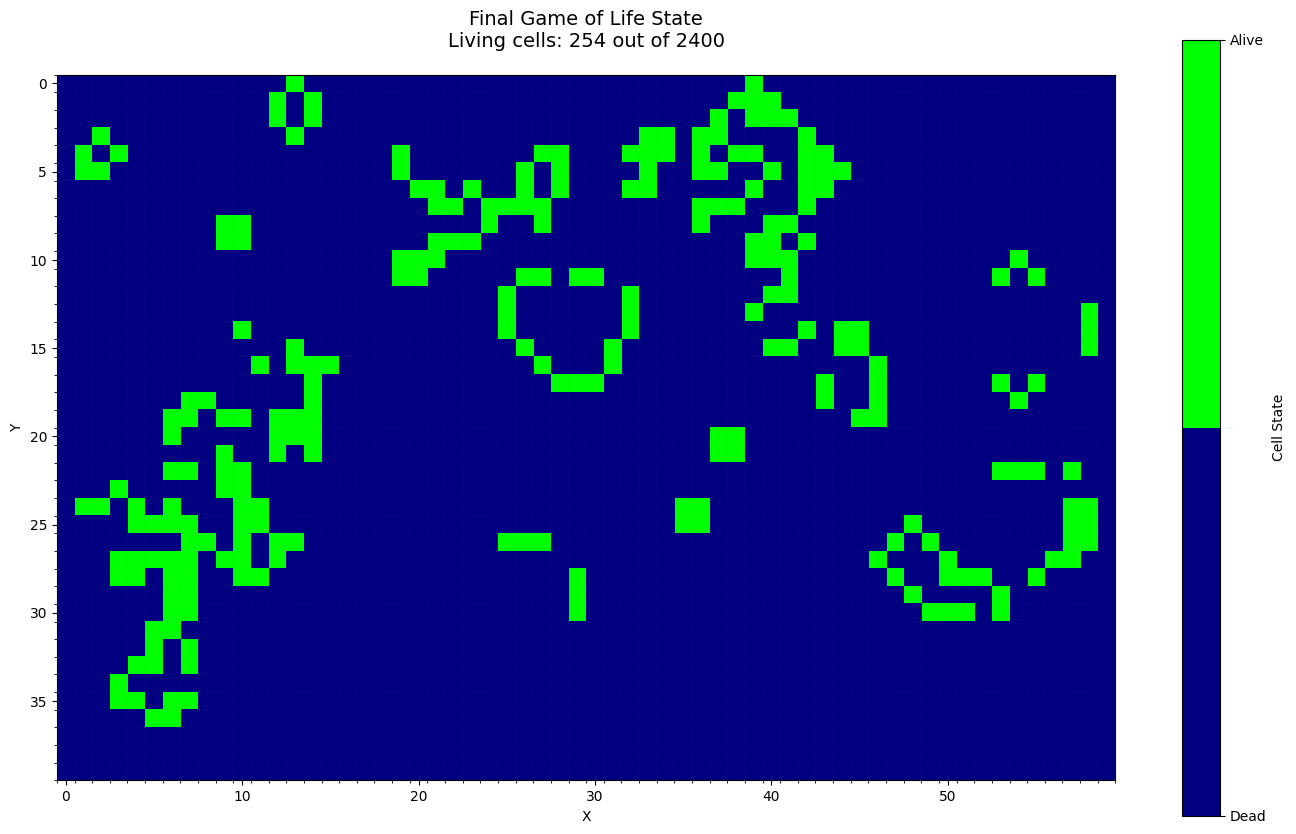

Animation saved successfully to: game_of_life_kinneret_simulation.gif

Download your GIF: computer:///mnt/user-data/outputs/game_of_life_kinneret_simulation.gif

📁 Your Game of Life animation:
computer:///mnt/user-data/outputs/game_of_life_kinneret_simulation.gif

🎮 GAME OF LIFE SIMULATION COMPLETE!
Simulation ran for 101 steps
Final living cells: 254


In [ ]:
"""
Game of Life Runner - Using Complete EcologicalCellularAutomata Class
Runs Conway's Game of Life with Firebase data from Lake Kinneret
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.animation import PillowWriter
import random
import json
from typing import Optional, List, Dict

def safe_float_convert(val):
    """Safely convert value to float"""
    try:
        return float(val) if val is not None else 0.0
    except (ValueError, TypeError):
        return 0.0

class EcologicalCellularAutomata:
    """
    Hybrid Cellular Automata supporting both:
    1. Environmental simulation with 7 Lake Kinneret parameters
    2. Classic Game of Life with binary states

    Parameters:
    - E.coli levels
    - Lake Level (m)
    - Lead (pb_ug_l_avg)
    - Flood events per month
    - Zinc (zn_ug_l_avg)
    - Depth (Depth_m)
    - Nitrate (avg_nitrate)
    """

    def __init__(self, width: int = 60, height: int = 40, seed: Optional[int] = None, mode: str = 'environmental'):
        self.width = width
        self.height = height
        self.mode = mode  # 'environmental' or 'game_of_life'

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        if mode == 'game_of_life':
            # Simple binary grid for Game of Life
            self.grid = np.zeros((height, width), dtype=int)  # 0 = dead, 1 = alive
            self.colormap = ListedColormap(['#000080', '#00FF00'])  # Dark blue for dead, green for alive
        else:
            # Environmental layers (only 7 parameters)
            self.ecoli_levels   = np.zeros((height, width), dtype=float)  # E.coli
            self.lake_level     = np.zeros((height, width), dtype=float)  # Lake Level (m)
            self.lead_levels    = np.zeros((height, width), dtype=float)  # Lead (pb_ug_l_avg)
            self.flood_events   = np.zeros((height, width), dtype=float)  # Flood events per month
            self.zinc_levels    = np.zeros((height, width), dtype=float)  # Zinc (zn_ug_l_avg)
            self.depth_map      = np.zeros((height, width), dtype=float)  # Depth (Depth_m)
            self.nitrate_levels = np.zeros((height, width), dtype=float)  # Nitrate (avg_nitrate)

            # Combined state (discrete 0..4)
            self.grid = np.zeros((height, width), dtype=int)
            self.colormap = ListedColormap(['#0066CC', '#00AACC', '#FFFF00', '#FF6600', '#CC0000'])

        self.history: List[np.ndarray] = []

        # Environmental dynamics parameters
        self.recovery_rate      = 0.025
        self.diffusion_rate     = 0.20
        self.flood_spread_factor= 0.40

        # Data compatibility
        self.real_data: Optional[Dict] = None
        self.step_years: List[int] = []

    def load_real_data(self, json_file='firebase.json', last_n_years: int = 13,
                      year_range: tuple = (2010, 2023)) -> bool:
        """Load data from JSON file with 13-year focus"""
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
        except FileNotFoundError:
            print("JSON file not found – using synthetic scenario")
            return False

        ecoli = self._extract_ecoli_floods(data)
        metals = self._extract_heavy_metals(data)
        chems = self._extract_chemicals(data)

        # Union of years across categories
        years = set()
        years.update([r['year'] for r in ecoli])
        years.update([r['year'] for r in metals])
        years.update([r['year'] for r in chems])
        all_years = sorted(list(years))

        # Apply year range filter (2010-2023)
        if year_range:
            min_year, max_year = year_range
            filtered_years = [y for y in all_years if min_year <= y <= max_year]
            print(f"Filtered to year range {year_range}: {len(filtered_years)} years")
        else:
            filtered_years = all_years

        # Take last N years (13 by default)
        if last_n_years and last_n_years > 0:
            self.step_years = filtered_years[-last_n_years:] if filtered_years else []
        else:
            self.step_years = filtered_years

        print(f"Using last {len(self.step_years)} years: {self.step_years}")
        print(f"Data coverage: {min(self.step_years)}-{max(self.step_years)}" if self.step_years else "No data")

        self.real_data = {'ecoli': ecoli, 'metals': metals, 'chemicals': chems}
        return True

    def _extract_ecoli_floods(self, data):
        """Extract E.coli and flood events data"""
        recs = []
        if 'Ecolifloods' in data:
            for year, ydata in data['Ecolifloods'].items():
                if not isinstance(ydata, list): continue
                for month_obj in ydata:
                    if not isinstance(month_obj, dict): continue
                    for _, day_list in month_obj.items():
                        if not isinstance(day_list, list): continue
                        for rec in day_list:
                            if isinstance(rec, dict):
                                recs.append({
                                    'year': int(year),
                                    'ecoli': safe_float_convert(rec.get('Ecoli')) or 0.0,
                                    'flood_events': safe_float_convert(rec.get('flood_in_month', 0)) or 0.0
                                })
        return recs

    def _extract_heavy_metals(self, data):
        """Extract heavy metals data (Lead, Zinc, Depth)"""
        recs = []
        if 'Heavy_Metals' in data:
            for _, site_blob in data['Heavy_Metals'].items():
                if not isinstance(site_blob, dict): continue
                for year_key, year_blob in site_blob.items():
                    days_dict = None
                    if isinstance(year_blob, list):
                        for item in year_blob:
                            if isinstance(item, dict):
                                days_dict = item
                                break
                    elif isinstance(year_blob, dict):
                        days_dict = year_blob
                    if not isinstance(days_dict, dict): continue
                    for _, day_list in days_dict.items():
                        if not isinstance(day_list, list): continue
                        for rec in day_list:
                            if isinstance(rec, dict):
                                recs.append({
                                    'year': int(year_key),
                                    'pb_ug_l_avg': safe_float_convert(rec.get('Pb_µg_L')) or 0.0,
                                    'zn_ug_l_avg': safe_float_convert(rec.get('Zn_µg_L')) or 0.0,
                                    'depth_m': safe_float_convert(rec.get('Depth_m')) or 0.0
                                })
        return recs

    def _extract_chemicals(self, data):
        """Extract chemical parameters data (Lake Level, Nitrate)"""
        recs = []
        if 'Chemicals_Height' in data:
            for year_key, year_blob in data['Chemicals_Height'].items():
                days_dict = None
                if isinstance(year_blob, list):
                    for item in year_blob:
                        if isinstance(item, dict):
                            days_dict = item
                            break
                elif isinstance(year_blob, dict):
                    days_dict = year_blob
                if not isinstance(days_dict, dict): continue
                for _, day_list in days_dict.items():
                    if not isinstance(day_list, list): continue
                    for rec in day_list:
                        if isinstance(rec, dict):
                            recs.append({
                                'year': int(year_key),
                                'lake_level_m': safe_float_convert(rec.get('kineret_height')),
                                'avg_nitrate': safe_float_convert(rec.get('avg_nitrate')) or 0.0
                            })
        return recs

    def initialize_from_data(self):
        """Initialize from data or create synthetic scenario"""
        if self.mode == 'game_of_life':
            self._initialize_game_of_life_from_data()
        else:
            self._initialize_environmental_from_data()

    def _initialize_game_of_life_from_data(self):
        """Initialize Game of Life from environmental data - using all 7 parameters"""
        if not self.real_data:
            self.create_synthetic_scenario()
            return

        # Initialize all environmental parameter arrays even in game_of_life mode
        self.ecoli_levels   = np.zeros((self.height, self.width), dtype=float)
        self.lake_level     = np.zeros((self.height, self.width), dtype=float)
        self.lead_levels    = np.zeros((self.height, self.width), dtype=float)
        self.flood_events   = np.zeros((self.height, self.width), dtype=float)
        self.zinc_levels    = np.zeros((self.height, self.width), dtype=float)
        self.depth_map      = np.zeros((self.height, self.width), dtype=float)
        self.nitrate_levels = np.zeros((self.height, self.width), dtype=float)

        # Extract all data types
        ecoli_data = self.real_data.get('ecoli', [])
        metals_data = self.real_data.get('metals', [])
        chemicals_data = self.real_data.get('chemicals', [])

        print(f"Initializing from data: {len(ecoli_data)} E.coli records, "
              f"{len(metals_data)} metals records, {len(chemicals_data)} chemical records")

        # Initialize from E.coli and flood data
        if ecoli_data:
            for i, r in enumerate(ecoli_data):
                x = i % self.width
                y = (i // self.width) % self.height
                if x < self.width and y < self.height:
                    self.ecoli_levels[y, x] = r.get('ecoli', 0.0)
                    self.flood_events[y, x] = r.get('flood_events', 0.0)

        # Initialize from metals data (Lead, Zinc, Depth)
        if metals_data:
            for i, r in enumerate(metals_data):
                x = i % self.width
                y = (i // self.width) % self.height
                if x < self.width and y < self.height:
                    self.lead_levels[y, x] = r.get('pb_ug_l_avg', 0.0)
                    self.zinc_levels[y, x] = r.get('zn_ug_l_avg', 0.0)
                    self.depth_map[y, x] = r.get('depth_m', 0.0)

        # Initialize from chemical data (Lake Level, Nitrate)
        if chemicals_data:
            for i, r in enumerate(chemicals_data):
                x = i % self.width
                y = (i // self.width) % self.height
                if x < self.width and y < self.height:
                    self.lake_level[y, x] = r.get('lake_level_m', 0.0) or 0.0
                    self.nitrate_levels[y, x] = r.get('avg_nitrate', 0.0)

        # Convert all parameters to binary Game of Life grid
        self.grid.fill(0)

        # Calculate thresholds for each parameter
        ecoli_threshold = np.mean(self.ecoli_levels[self.ecoli_levels > 0]) if np.any(self.ecoli_levels > 0) else 0
        lake_threshold = np.mean(self.lake_level[self.lake_level > 0]) if np.any(self.lake_level > 0) else 0
        lead_threshold = np.mean(self.lead_levels[self.lead_levels > 0]) if np.any(self.lead_levels > 0) else 0
        flood_threshold = np.mean(self.flood_events[self.flood_events > 0]) if np.any(self.flood_events > 0) else 0
        zinc_threshold = np.mean(self.zinc_levels[self.zinc_levels > 0]) if np.any(self.zinc_levels > 0) else 0
        depth_threshold = np.mean(self.depth_map[self.depth_map > 0]) if np.any(self.depth_map > 0) else 0
        nitrate_threshold = np.mean(self.nitrate_levels[self.nitrate_levels > 0]) if np.any(self.nitrate_levels > 0) else 0

        print(f"Thresholds - E.coli: {ecoli_threshold:.2f}, Lake: {lake_threshold:.2f}, "
              f"Lead: {lead_threshold:.2f}, Flood: {flood_threshold:.2f}")
        print(f"           Zinc: {zinc_threshold:.2f}, Depth: {depth_threshold:.2f}, "
              f"Nitrate: {nitrate_threshold:.2f}")

        # Convert to binary based on multiple criteria
        for y in range(self.height):
            for x in range(self.width):
                # Count how many parameters exceed their thresholds
                score = 0
                if self.ecoli_levels[y, x] > ecoli_threshold: score += 1
                if self.lake_level[y, x] > lake_threshold: score += 1
                if self.lead_levels[y, x] > lead_threshold: score += 1
                if self.flood_events[y, x] > flood_threshold: score += 1
                if self.zinc_levels[y, x] > zinc_threshold: score += 1
                if self.depth_map[y, x] > depth_threshold: score += 1
                if self.nitrate_levels[y, x] > nitrate_threshold: score += 1

                # Cell is "alive" if at least 3 out of 7 parameters exceed threshold
                # or if any critical parameter (E.coli, Lead) is very high
                critical_condition = (self.ecoli_levels[y, x] > ecoli_threshold * 1.5 or
                                    self.lead_levels[y, x] > lead_threshold * 1.5)

                self.grid[y, x] = 1 if (score >= 3 or critical_condition) else 0

        # Add some random noise if too sparse
        living_cells = np.sum(self.grid)
        total_cells = self.width * self.height
        density = living_cells / total_cells

        if density < 0.1:  # If less than 10% alive, add some randomness
            for y in range(self.height):
                for x in range(self.width):
                    if self.grid[y, x] == 0 and random.random() < 0.08:
                        self.grid[y, x] = 1
            living_cells = np.sum(self.grid)

        print(f"Initialized Game of Life with {living_cells} living cells out of {total_cells}")
        print(f"Cell density: {(living_cells/total_cells)*100:.1f}%")

        # Print parameter statistics
        print("\nParameter Statistics:")
        print(f"E.coli: min={np.min(self.ecoli_levels):.2f}, max={np.max(self.ecoli_levels):.2f}, mean={np.mean(self.ecoli_levels):.2f}")
        print(f"Lake Level: min={np.min(self.lake_level):.2f}, max={np.max(self.lake_level):.2f}, mean={np.mean(self.lake_level):.2f}")
        print(f"Lead: min={np.min(self.lead_levels):.2f}, max={np.max(self.lead_levels):.2f}, mean={np.mean(self.lead_levels):.2f}")
        print(f"Flood Events: min={np.min(self.flood_events):.2f}, max={np.max(self.flood_events):.2f}, mean={np.mean(self.flood_events):.2f}")
        print(f"Zinc: min={np.min(self.zinc_levels):.2f}, max={np.max(self.zinc_levels):.2f}, mean={np.mean(self.zinc_levels):.2f}")
        print(f"Depth: min={np.min(self.depth_map):.2f}, max={np.max(self.depth_map):.2f}, mean={np.mean(self.depth_map):.2f}")
        print(f"Nitrate: min={np.min(self.nitrate_levels):.2f}, max={np.max(self.nitrate_levels):.2f}, mean={np.mean(self.nitrate_levels):.2f}")

    def create_synthetic_scenario(self):
        """Create synthetic scenario"""
        if self.mode == 'game_of_life':
            self._create_synthetic_game_of_life()

    def _create_synthetic_game_of_life(self):
        """Create synthetic Game of Life scenario with famous patterns"""
        print("Creating synthetic Game of Life scenario")
        self.grid.fill(0)

        # Random initialization
        for y in range(self.height):
            for x in range(self.width):
                if random.random() < 0.15:  # 15% chance to be alive
                    self.grid[y, x] = 1

        # Add famous patterns
        self._add_pattern('glider', 5, 5)
        self._add_pattern('glider', 15, 8)
        self._add_pattern('blinker', 25, 12)
        self._add_pattern('block', 35, 15)
        self._add_pattern('toad', 10, 25)
        self._add_pattern('beacon', 30, 25)

        self.step_years = []
        print(f"Synthetic scenario created with {np.sum(self.grid)} living cells")

    def _add_pattern(self, pattern_name: str, x: int, y: int):
        """Add famous Game of Life patterns"""
        patterns = {
            'glider': [
                [0, 1, 0],
                [0, 0, 1],
                [1, 1, 1]
            ],
            'block': [
                [1, 1],
                [1, 1]
            ],
            'blinker': [
                [1, 1, 1]
            ],
            'toad': [
                [0, 1, 1, 1],
                [1, 1, 1, 0]
            ],
            'beacon': [
                [1, 1, 0, 0],
                [1, 1, 0, 0],
                [0, 0, 1, 1],
                [0, 0, 1, 1]
            ]
        }

        if pattern_name not in patterns:
            return

        pattern = np.array(patterns[pattern_name])
        h, w = pattern.shape

        # Check boundaries
        if x + w > self.width or y + h > self.height:
            return

        # Add pattern to grid
        self.grid[y:y+h, x:x+w] = pattern

    def _count_neighbors(self, x: int, y: int) -> int:
        """Count living neighbors (8-connected)"""
        count = 0
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue  # Don't count the cell itself

                nx, ny = x + dx, y + dy

                # Check boundaries
                if 0 <= nx < self.width and 0 <= ny < self.height:
                    count += self.grid[ny, nx]

        return count

    def update_step(self):
        """Single simulation step"""
        if self.mode == 'game_of_life':
            self._update_game_of_life_step()

    def _update_game_of_life_step(self):
        """Single Game of Life step"""
        new_grid = np.zeros_like(self.grid)

        for y in range(self.height):
            for x in range(self.width):
                neighbors = self._count_neighbors(x, y)
                current_cell = self.grid[y, x]

                # Classic Game of Life rules
                if current_cell == 1:  # Living cell
                    if neighbors == 2 or neighbors == 3:
                        new_grid[y, x] = 1  # Survival
                    else:
                        new_grid[y, x] = 0  # Death (loneliness or overcrowding)
                else:  # Dead cell
                    if neighbors == 3:
                        new_grid[y, x] = 1  # Birth
                    else:
                        new_grid[y, x] = 0  # Stays dead

        self.grid = new_grid
        self.history.append(self.grid.copy())

    def run_simulation(self, steps: Optional[int] = None):
        """Run complete simulation (optimized for 13-year data)"""
        if steps is None:
            steps = 50  # Default for Game of Life

        self.history = [self.grid.copy()]

        print(f"Running Game of Life simulation for {steps} steps...")

        for step in range(steps):
            prev_state = self.grid.copy()
            self.update_step()

            # Check if simulation stabilized
            if np.array_equal(self.grid, prev_state):
                print(f"Simulation stabilized at step {step + 1}")
                break

            # Check if all cells died (Game of Life only)
            if np.sum(self.grid) == 0:
                print(f"All cells died at step {step + 1}")
                break

            # Check for 2-step cycle
            if len(self.history) >= 3 and np.array_equal(self.grid, self.history[-3]):
                print(f"2-step cycle detected at step {step + 1}")
                break

        print(f"Simulation completed after {len(self.history)} steps")
        print(f"Living cells at end: {np.sum(self.grid)}")
        return len(self.history)

    def visualize_variables(self, title="Game of Life State"):
        """Visualize current state"""
        fig, ax = plt.subplots(figsize=(14, 10))

        # Display grid
        im = ax.imshow(self.grid, cmap=self.colormap, vmin=0, vmax=1, interpolation='nearest')

        alive_count = np.sum(self.grid)
        ax.set_title(f'{title}\nLiving cells: {alive_count} out of {self.width * self.height}',
                    fontsize=14, pad=20)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')

        # Add subtle grid lines
        ax.set_xticks(np.arange(-0.5, self.width, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.height, 1), minor=True)
        ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.1, alpha=0.3)

        # Colorbar
        cbar = plt.colorbar(im, ax=ax, ticks=[0, 1], shrink=0.8)
        cbar.set_label('Cell State')
        cbar.set_ticklabels(['Dead', 'Alive'])

        plt.tight_layout()
        plt.show()

    def export_gif(self, path=None, fps=2, dpi=100):
        """Export to GIF file with download capability"""
        if len(self.history) < 2:
            print("Run simulation first")
            return None

        if path is None:
            path = f"game_of_life_kinneret_simulation.gif"

        try:
            # Create animation without showing it
            fig, ax = plt.subplots(figsize=(12, 8))

            im = ax.imshow(self.history[0], cmap=self.colormap, vmin=0, vmax=1,
                          interpolation='nearest')

            ax.set_title("Game of Life - Lake Kinneret Data Evolution")
            ax.set_xlabel('X')
            ax.set_ylabel('Y')

            # Dynamic information display
            text = ax.text(0.02, 0.98, '', transform=ax.transAxes,
                          fontsize=12, verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

            def animate(frame):
                im.set_array(self.history[frame])

                alive_cells = np.sum(self.history[frame])
                total_cells = self.width * self.height
                percentage = (alive_cells / total_cells) * 100
                text.set_text(f'Step: {frame}\nLiving cells: {alive_cells}\nAlive %: {percentage:.1f}%')

                return [im, text]

            anim = animation.FuncAnimation(fig, animate, frames=len(self.history),
                                         interval=1000//fps, blit=True, repeat=True)

            # Use PillowWriter for GIF export
            writer = PillowWriter(fps=fps)
            anim.save(path, writer=writer, dpi=dpi)
            plt.close()

            print(f"Animation saved successfully to: {path}")

            # Create download link
            filename = path.split('/')[-1]
            print(f"\nDownload your GIF: computer:///mnt/user-data/outputs/{filename}")
            return path

        except Exception as e:
            print(f"Error saving GIF: {e}")
            return None

def main_game_of_life():
    """Main Game of Life runner"""
    print("🎮 GAME OF LIFE - LAKE KINNERET")
    print("=" * 50)

    # Create Game of Life instance
    model = EcologicalCellularAutomata(width=60, height=40, seed=42, mode='game_of_life')

    # Try to load Firebase data
    if model.load_real_data('firebase_data.json'):
        print("✅ Firebase data loaded successfully!")
        model.initialize_from_data()
    else:
        print("Using synthetic Game of Life scenario...")
        model.create_synthetic_scenario()

    # Show initial state
    model.visualize_variables("Initial Game of Life State")

    # Run simulation
    steps = model.run_simulation(steps=100)

    # Show final state
    model.visualize_variables("Final Game of Life State")

    # Create animation GIF
    gif_path = model.export_gif(fps=5, dpi=120)

    if gif_path:
        filename = gif_path.split('/')[-1]
        print(f"\n📁 Your Game of Life animation:")
        print(f"computer:///mnt/user-data/outputs/{filename}")

    print("\n" + "=" * 50)
    print("🎮 GAME OF LIFE SIMULATION COMPLETE!")
    print(f"Simulation ran for {steps} steps")
    print(f"Final living cells: {np.sum(model.grid)}")

    return model

if __name__ == "__main__":
    main_game_of_life()

## Cellular Automata Enviromental Analysis

Each environmental variable follows specific update rules during each simulation step:
E.coli: Spreads to neighboring cells through diffusion, increases during flood events, and naturally decays over time due to die-off and environmental factors.
Floods: Spread rapidly to adjacent areas when they occur, then gradually subside with a decay factor.
Heavy Metals: Diffuse slowly between cells and recover very gradually, reflecting their persistent nature in aquatic systems.
Chloride/Nitrate: Accumulate under specific environmental conditions (shallow areas with adequate water levels) and decay at different rates, with nitrate decaying faster due to biological uptake.
Pollution Index Calculation
The simulation combines all variables into a unified pollution state using weighted contributions:

E.coli: 25%
Lead: 20%
Nitrate: 15%
Chloride: 15%
Flood: 15%
Zinc: 10%

Water depth and lake height act as modifying factors - deeper areas tend to concentrate pollutants, while low water levels increase concentration effects.
The final pollution index is discretized into five levels (0=clean, 1=low, 2=moderate, 3=high, 4=critical) for visualization.
Temporal Evolution
The simulation runs step-by-step, where each step represents a time period (typically years when using real data). At each step:

Each variable updates according to its diffusion and decay rules
Variables interact (e.g., floods enhance E.coli spread)
The combined pollution state is recalculated
The current state is saved to history for animation

Visualization Capabilities
The system produces multiple visualization types:

Individual variable maps showing spatial distribution of each pollutant
Combined state maps showing overall pollution levels
Time-series animations showing evolution over multiple years
Statistical summaries of pollution levels

In [ ]:
class EcologicalCellularAutomata:
    """
    Cellular Automata tailored to environmental variables:
    E.coli, Floods, Heavy Metals (Pb, Zn), Depth, Chloride, Lake Height
    """

    def __init__(self, width: int = 60, height: int = 40, seed: Optional[int] = None):
        self.width = width
        self.height = height
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        # Initialize layers
        self.ecoli_levels   = np.zeros((height, width), dtype=float)
        self.flood_impact   = np.zeros((height, width), dtype=float)
        self.lead_levels    = np.zeros((height, width), dtype=float)
        self.zinc_levels    = np.zeros((height, width), dtype=float)
        self.depth_map      = np.zeros((height, width), dtype=float)
        self.Chloride    = np.zeros((height, width), dtype=float)
        self.Nitrate     = np.zeros((height, width), dtype=float)
        self.lake_height    = np.zeros((height, width), dtype=float)

        # Combined state (discrete 0..4)
        self.grid = np.zeros((height, width), dtype=int)
        self.history: List[np.ndarray] = []

        # Dynamics parameters
        self.recovery_rate      = 0.025
        self.diffusion_rate     = 0.20
        self.flood_spread_factor= 0.40

        # Visualization
        self.colormap = ListedColormap(['#0066CC', '#00AACC', '#FFFF00', '#FF6600', '#CC0000'])

        # Data holders
        self.real_data: Optional[Dict] = None
        self.step_years: List[int] = []

    def load_real_data(self, json_file='firebase.json') -> bool:
        """Load data from JSON file into structured lists"""
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
        except FileNotFoundError:
            print("JSON not found – using synthetic scenario.")
            return False

        ecoli = self._extract_ecoli_floods(data)
        metals= self._extract_heavy_metals(data)
        chems = self._extract_chemicals(data)

        # Union years across categories
        years = set()
        years.update([r['year'] for r in ecoli])
        years.update([r['year'] for r in metals])
        years.update([r['year'] for r in chems])
        self.step_years = sorted(list(years))

        self.real_data = {'ecoli': ecoli, 'metals': metals, 'chemicals': chems}
        return True

    def _extract_ecoli_floods(self, data):
        """Extract E.coli and flood data"""
        recs = []
        if 'Ecolifloods' in data:
            for year, ydata in data['Ecolifloods'].items():
                if not isinstance(ydata, list): continue
                for month_obj in ydata:
                    if not isinstance(month_obj, dict): continue
                    for _, day_list in month_obj.items():
                        if not isinstance(day_list, list): continue
                        for rec in day_list:
                            if isinstance(rec, dict):
                                recs.append({
                                    'year': int(year),
                                    'ecoli': safe_float_convert(rec.get('Ecoli')) or 0.0,
                                    'flood': safe_float_convert(rec.get('flood_in_month',0)) or 0.0
                                })
        return recs

    def _extract_heavy_metals(self, data):
        """Extract heavy metals data"""
        recs = []
        if 'Heavy_Metals' in data:
            for _, site_blob in data['Heavy_Metals'].items():
                if not isinstance(site_blob, dict): continue
                for year_key, year_blob in site_blob.items():
                    days_dict = None
                    if isinstance(year_blob, list):
                        for item in year_blob:
                            if isinstance(item, dict):
                                days_dict = item; break
                    elif isinstance(year_blob, dict):
                        days_dict = year_blob
                    if not isinstance(days_dict, dict): continue
                    for _, day_list in days_dict.items():
                        if not isinstance(day_list, list): continue
                        for rec in day_list:
                            if isinstance(rec, dict):
                                recs.append({
                                    'year': int(year_key),
                                    'pb':   safe_float_convert(rec.get('Pb_µg_L')) or 0.0,
                                    'zn':   safe_float_convert(rec.get('Zn_µg_L')) or 0.0,
                                    'depth':safe_float_convert(rec.get('Depth_m')) or 0.0
                                })
        return recs

    def _extract_chemicals(self, data):
        """Extract chemical parameters data"""
        recs = []
        if 'Chemicals_Height' in data:
            for year_key, year_blob in data['Chemicals_Height'].items():
                days_dict = None
                if isinstance(year_blob, list):
                    for item in year_blob:
                        if isinstance(item, dict):
                            days_dict = item; break
                elif isinstance(year_blob, dict):
                    days_dict = year_blob
                if not isinstance(days_dict, dict): continue
                for _, day_list in days_dict.items():
                    if not isinstance(day_list, list): continue
                    for rec in day_list:
                        if isinstance(rec, dict):
                            recs.append({
                                'year': int(year_key),
                                'Chloride': safe_float_convert(rec.get('chl_ug_l_avg')) or 0.0,
                                'Nitrate': safe_float_convert(rec.get('avg_nitrate')) or 0.0,
                                'lake_height': safe_float_convert(rec.get('kineret_height'))
                            })
        return recs

    def initialize_from_data(self):
        """Project loaded data into rasters"""
        if not self.real_data:
            self.create_synthetic_scenario()
            return

        # Clear grids
        for grid in [self.ecoli_levels, self.flood_impact, self.lead_levels,
                     self.zinc_levels, self.depth_map, self.Chloride, self.Nitrate, self.lake_height]:
            grid.fill(0)

        # Map year to x index
        years = self.step_years if self.step_years else list(range(2009, 2009+self.width))
        y_min, y_max = min(years), max(years)
        def year_to_x(y):
            if y_max == y_min: return 0
            return int((y - y_min) / (y_max - y_min) * (self.width - 1))

        # Process E.coli + Floods
        if self.real_data['ecoli']:
            ecoli = self.real_data['ecoli']
            max_ecoli = max([r['ecoli'] for r in ecoli if r['ecoli']>0], default=1.0)
            for r in ecoli:
                x = year_to_x(r['year'])
                ecoli_norm = (r['ecoli']/max_ecoli) if max_ecoli>0 else 0.0
                y = int(ecoli_norm * (self.height - 1) * 0.8)
                self._add_spot(self.ecoli_levels, x, y, ecoli_norm, 3)
                if r['flood']>0:
                    self._add_spot(self.flood_impact, x, y, 1.0, 5)

        # Process Metals
        if self.real_data['metals']:
            metals = self.real_data['metals']
            max_pb = max([r['pb'] for r in metals if r['pb']>0], default=1.0)
            max_zn = max([r['zn'] for r in metals if r['zn']>0], default=1.0)
            for r in metals:
                x = year_to_x(r['year'])
                if r['pb']>0:
                    pb_norm = r['pb']/max_pb
                    y = int(self.height*0.30 + pb_norm*self.height*0.40)
                    self._add_spot(self.lead_levels, x, y, pb_norm, 2)
                if r['zn']>0:
                    zn_norm = r['zn']/max_zn
                    y = int(self.height*0.40 + zn_norm*self.height*0.30)
                    self._add_spot(self.zinc_levels, x, y, zn_norm, 2)
                if r['depth']>0:
                    depth_norm = min(r['depth']/10.0, 1.0)
                    self._add_spot(self.depth_map, x, int(self.height*0.6), depth_norm, 4)

        # Process Chemicals
        if self.real_data['chemicals']:
            chems = self.real_data['chemicals']
            max_chl = max([r['Chloride'] for r in chems if r['Chloride']>0], default=1.0)
            max_nitrate = max([r['Nitrate'] for r in chems if r['Nitrate']>0], default=1.0)

            lh_vals = [r['lake_height'] for r in chems if isinstance(r['lake_height'], (int, float))]
            if lh_vals:
                lh_min, lh_max = min(lh_vals), max(lh_vals)
            else:
                lh_min, lh_max = -215.0, -208.0  # Fallback Kinneret range

            for r in chems:
                x = year_to_x(r['year'])
                if r['Chloride']>0:
                    chl_norm = r['Chloride']/max_chl
                    y = int(self.height*0.2 + chl_norm*self.height*0.3)
                    self._add_spot(self.Chloride, x, y, chl_norm, 3)

                if r['Nitrate']>0:
                    nitrate_norm = r['Nitrate']/max_nitrate
                    y = int(self.height*0.4 + nitrate_norm*self.height*0.3)
                    self._add_spot(self.Nitrate, x, y, nitrate_norm, 3)

                lh = r['lake_height']
                if isinstance(lh, (int, float)) and lh_max != lh_min:
                    h_norm = np.clip((lh - lh_min) / (lh_max - lh_min), 0.0, 1.0)
                    self.lake_height[:, x] = np.maximum(self.lake_height[:, x], h_norm)

        self._update_combined()

    def _norm01(self, A):
      A = np.asarray(A)
      Amin, Amax = np.nanmin(A), np.nanmax(A)
      return (A - Amin) / (Amax - Amin + 1e-9)

    def _make_depth_field(self, X, Y):
      depth_raw = 1.0 - ((X/8.0)**2 + ((Y+1.0)/5.0)**2)
      depth = np.clip(depth_raw, 0, 1)
      return depth

    def _make_lake_level_field(self, X, Y, scenario):
      level = np.exp(-((X/9.0)**2 + (Y/6.5)**2))
      level = self._norm01(level)
      if scenario == 'stress':
          level *= 0.85
      elif scenario == 'recovery':
          level *= 1.05
      return np.clip(level, 0, 1)


    def create_synthetic_scenario(self):
        """Create synthetic scenario when no real data is available"""
        for grid in [self.ecoli_levels, self.flood_impact, self.lead_levels,
                     self.zinc_levels, self.depth_map, self.Chloride, self.Nitrate, self.lake_height]:
            grid.fill(0)

        # Generate synthetic data patterns
        for _ in range(3):
            self._add_spot(self.ecoli_levels,
                           random.randint(5, self.width-5),
                           random.randint(5, self.height//2),
                           random.uniform(0.5,1.0), 3)
        for _ in range(2):
            self._add_spot(self.flood_impact,
                           random.randint(10, self.width-10),
                           random.randint(0, self.height-1),
                           1.0, 8)
        for _ in range(2):
            x = random.randint(5, self.width-5)
            y = random.randint(self.height//3, 2*self.height//3)
            self._add_spot(self.lead_levels, x, y, random.uniform(0.4,0.8), 2)
            self._add_spot(self.zinc_levels, x, y, random.uniform(0.3,0.7), 2)

        # Depth map
        for x in range(self.width):
            for y in range(self.height):
                val = 0.3 + 0.4*np.sin(x*0.1)*np.cos(y*0.1)
                self.depth_map[y,x] = np.clip(val, 0, 1)

        #Chloride
        for _ in range(2):
            self._add_spot(self.Chloride,
                           random.randint(5, self.width-5),
                           random.randint(5, self.height-5),
                           random.uniform(0.6,1.0), 4)

        #Nitrate
        for _ in range(2):
            self._add_spot(self.Nitrate,
                           random.randint(5, self.width-5),
                           random.randint(5, self.height-5),
                           random.uniform(0.5,0.9), 4)

        # Lake height
        base = 0.7
        for x in range(self.width):
            hv = 0.1*np.sin(x*0.2)
            self.lake_height[:, x] = base + hv

        self._update_combined()
        self.step_years = []

    def _add_spot(self, grid, cx, cy, intensity, radius):
        """Add a circular spot to a grid"""
        for dy in range(-radius, radius+1):
            for dx in range(-radius, radius+1):
                x, y = cx+dx, cy+dy
                if 0<=x<self.width and 0<=y<self.height:
                    d = np.hypot(dx, dy)
                    if d <= radius:
                        grid[y,x] = max(grid[y,x], intensity * max(0, 1 - d/radius))

    def _update_combined(self):
        """Combine all layers into discrete state grid"""
        E,F,Pb,Zn,Ch,Ni,Depth,H = (self.ecoli_levels, self.flood_impact, self.lead_levels,
                                self.zinc_levels, self.Chloride, self.Nitrate, self.depth_map, self.lake_height)

        for y in range(self.height):
            pol = (E[y]*0.25 + Pb[y]*0.20 + Zn[y]*0.10 + Ch[y]*0.15 + Ni[y]*0.15 + F[y]*0.15)
            pol *= (1 + Depth[y]*0.30) * (2 - H[y])
            g = np.zeros(self.width, dtype=int)
            g[pol>=0.2] = 1
            g[pol>=0.4] = 2
            g[pol>=0.6] = 3
            g[pol>=0.8] = 4
            self.grid[y] = g

    def _neighbors(self, x, y):
        """Get neighboring cells"""
        for dy in (-1,0,1):
            for dx in (-1,0,1):
                if dx==0 and dy==0: continue
                nx, ny = x+dx, y+dy
                if 0<=nx<self.width and 0<=ny<self.height:
                    yield nx, ny

    def _update_ecoli(self):
        """Update E.coli diffusion and recovery"""
        newE = self.ecoli_levels.copy()
        for y in range(self.height):
            for x in range(self.width):
                neigh = list(self._neighbors(x,y))
                if neigh:
                    avg = np.mean([self.ecoli_levels[ny,nx] for nx,ny in neigh])
                    if avg > self.ecoli_levels[y,x]:
                        newE[y,x] += (avg - self.ecoli_levels[y,x])*self.diffusion_rate
                    if self.flood_impact[y,x] > 0.5:
                        newE[y,x] += 0.1
                newE[y,x] *= (1 - self.recovery_rate)
        self.ecoli_levels = np.clip(newE, 0, 1)

    def _update_floods(self):
        """Update flood spread and decay"""
        newF = self.flood_impact.copy()
        for y in range(self.height):
            for x in range(self.width):
                neigh = list(self._neighbors(x,y))
                if neigh:
                    m = max([self.flood_impact[ny,nx] for nx,ny in neigh])
                    if m > self.flood_impact[y,x]:
                        newF[y,x] += (m - self.flood_impact[y,x]) * self.flood_spread_factor
                newF[y,x] *= 0.95
        self.flood_impact = np.clip(newF, 0, 1)

    def _update_metals(self):
        """Update heavy metals diffusion and recovery"""
        for metal in (self.lead_levels, self.zinc_levels):
            newM = metal.copy()
            for y in range(self.height):
                for x in range(self.width):
                    neigh = list(self._neighbors(x,y))
                    if neigh:
                        avg = np.mean([metal[ny,nx] for nx,ny in neigh])
                        if avg > metal[y,x]:
                            newM[y,x] += (avg - metal[y,x]) * self.diffusion_rate * 0.5
                    newM[y,x] *= (1 - self.recovery_rate*0.3)
            if metal is self.lead_levels:
                self.lead_levels = np.clip(newM, 0, 1)
            else:
                self.zinc_levels = np.clip(newM, 0, 1)

    def _update_chl(self):
        """Update Chloride growth and decay"""
        newC = self.Chloride.copy()
        for y in range(self.height):
            for x in range(self.width):
                if self.lake_height[y,x] > 0.5 and self.depth_map[y,x] < 0.7:
                    neigh = list(self._neighbors(x,y))
                    if neigh:
                        avg = np.mean([self.Chloride[ny,nx] for nx,ny in neigh])
                        newC[y,x] += avg * 0.1
                newC[y,x] *= (1 - self.recovery_rate*2)
        self.Chloride = np.clip(newC, 0, 1)

    def _update_nitrate(self):
        """Update Nitrate growth and decay"""
        newN = self.Nitrate.copy()
        for y in range(self.height):
            for x in range(self.width):
                if self.lake_height[y,x] > 0.4 and self.depth_map[y,x] < 0.8:
                    neigh = list(self._neighbors(x,y))
                    if neigh:
                        avg = np.mean([self.Nitrate[ny,nx] for nx,ny in neigh])
                        newN[y,x] += avg * 0.12
                newN[y,x] *= (1 - self.recovery_rate*1.5)
        self.Nitrate = np.clip(newN, 0, 1)

    def update_step(self):
        """Single simulation step"""
        self._update_ecoli()
        self._update_floods()
        self._update_metals()
        self._update_chl()
        self._update_nitrate()
        self._update_combined()
        self.history.append(self.grid.copy())

    def run_simulation(self, steps: Optional[int] = None):
        """Run complete simulation"""
        if steps is None:
            steps = len(self.step_years) if self.step_years else 25
        self.history = [self.grid.copy()]
        for _ in range(steps):
            self.update_step()
        return len(self.history)

    def visualize_variables(self, title="Environmental Variables"):
        """Visualize all environmental variable layers"""
        fig, axes = plt.subplots(3, 3, figsize=(18,12))
        axes = axes.flatten()
        vars_to_show = [
            (self.ecoli_levels,  'E.coli Levels',  'Reds'),
            (self.flood_impact,  'Flood Impact',   'Blues'),
            (self.lead_levels,   'Lead (Pb)',      'Oranges'),
            (self.zinc_levels,   'Zinc (Zn)',      'Purples'),
            (self.depth_map,     'Depth Map',      'viridis'),
            (self.Chloride,      'Chloride',       'Greens'),
            (self.Nitrate,       'Nitrate',        'YlOrRd'),
            (self.lake_height,   'Lake Height',    'Blues_r'),
            (self.grid,          'Combined State', self.colormap),
        ]
        for i,(grid,name,cmap) in enumerate(vars_to_show):
            im = axes[i].imshow(grid, cmap=cmap, aspect='equal')
            axes[i].set_title(name)
            axes[i].set_xlabel('X')
            axes[i].set_ylabel('Y')
            plt.colorbar(im, ax=axes[i], shrink=0.8)
        plt.suptitle(title, fontsize=16)
        plt.tight_layout()
        plt.show()

    def create_animation(self, interval=800, fps=2, show_inline=True):
        """Create animation of simulation evolution"""
        if len(self.history) < 2:
            print("Run simulation first.")
            return None

        fig, ax = plt.subplots(figsize=(10,6))
        im = ax.imshow(self.history[0], cmap=self.colormap, vmin=0, vmax=4,
                      interpolation='nearest', aspect='equal', animated=True)
        fig.colorbar(im, ax=ax).set_label('Pollution State (0..4)')
        title = ax.set_title('Environmental Pollution Evolution')

        stats_txt = ax.text(0.02, 0.98, '', transform=ax.transAxes,
                            va='top', ha='left',
                            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                            animated=True)

        def _stats(grid):
            u, c = np.unique(grid, return_counts=True)
            total = grid.size
            def pct(val):
                return (c[u==val][0]/total*100) if val in u else 0.0
            return f'Clean: {pct(0):.1f}%\nCritical: {pct(4):.1f}%'

        def init():
            im.set_data(self.history[0])
            year = self.step_years[0] if self.step_years else 2010
            title.set_text(f'Environmental Pollution Evolution - Year {year}')
            stats_txt.set_text(_stats(self.history[0]))
            return (im, title, stats_txt)

        def update(i):
            g = self.history[i]
            im.set_data(g)
            if self.step_years:
                year = self.step_years[i] if i < len(self.step_years) else self.step_years[-1]
            else:
                year = 2010 + i
            title.set_text(f'Environmental Pollution Evolution - Year {year}')
            stats_txt.set_text(_stats(g))
            return (im, title, stats_txt)

        anim = animation.FuncAnimation(fig, update, init_func=init,
                                      frames=len(self.history),
                                      interval=interval, blit=True, repeat=True)
        self._animation = anim
        if show_inline:
            display(HTML(anim.to_jshtml()))
        return anim

    def export_gif(self, path=None, fps=2, dpi=140):
        """Export animation as GIF"""
        if not hasattr(self, "_animation") or self._animation is None:
            print("No animation object – calling create_animation() first.")
            self.create_animation(show_inline=False, fps=fps)
        if path is None:
            if self.step_years:
                start, end = self.step_years[0], self.step_years[-1]
                path = f"kineret_{start}_{end}.gif"
            else:
                path = "kineret_ca.gif"
        self._animation.save(path, writer=PillowWriter(fps=fps), dpi=dpi)
        print(f"GIF saved to: {path}")

Running Cellular Automata Simulation with Firebase data (2010-2023)...
Filtered to years (2010, 2023): [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Using Firebase data. Years analyzed: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Total years: 14


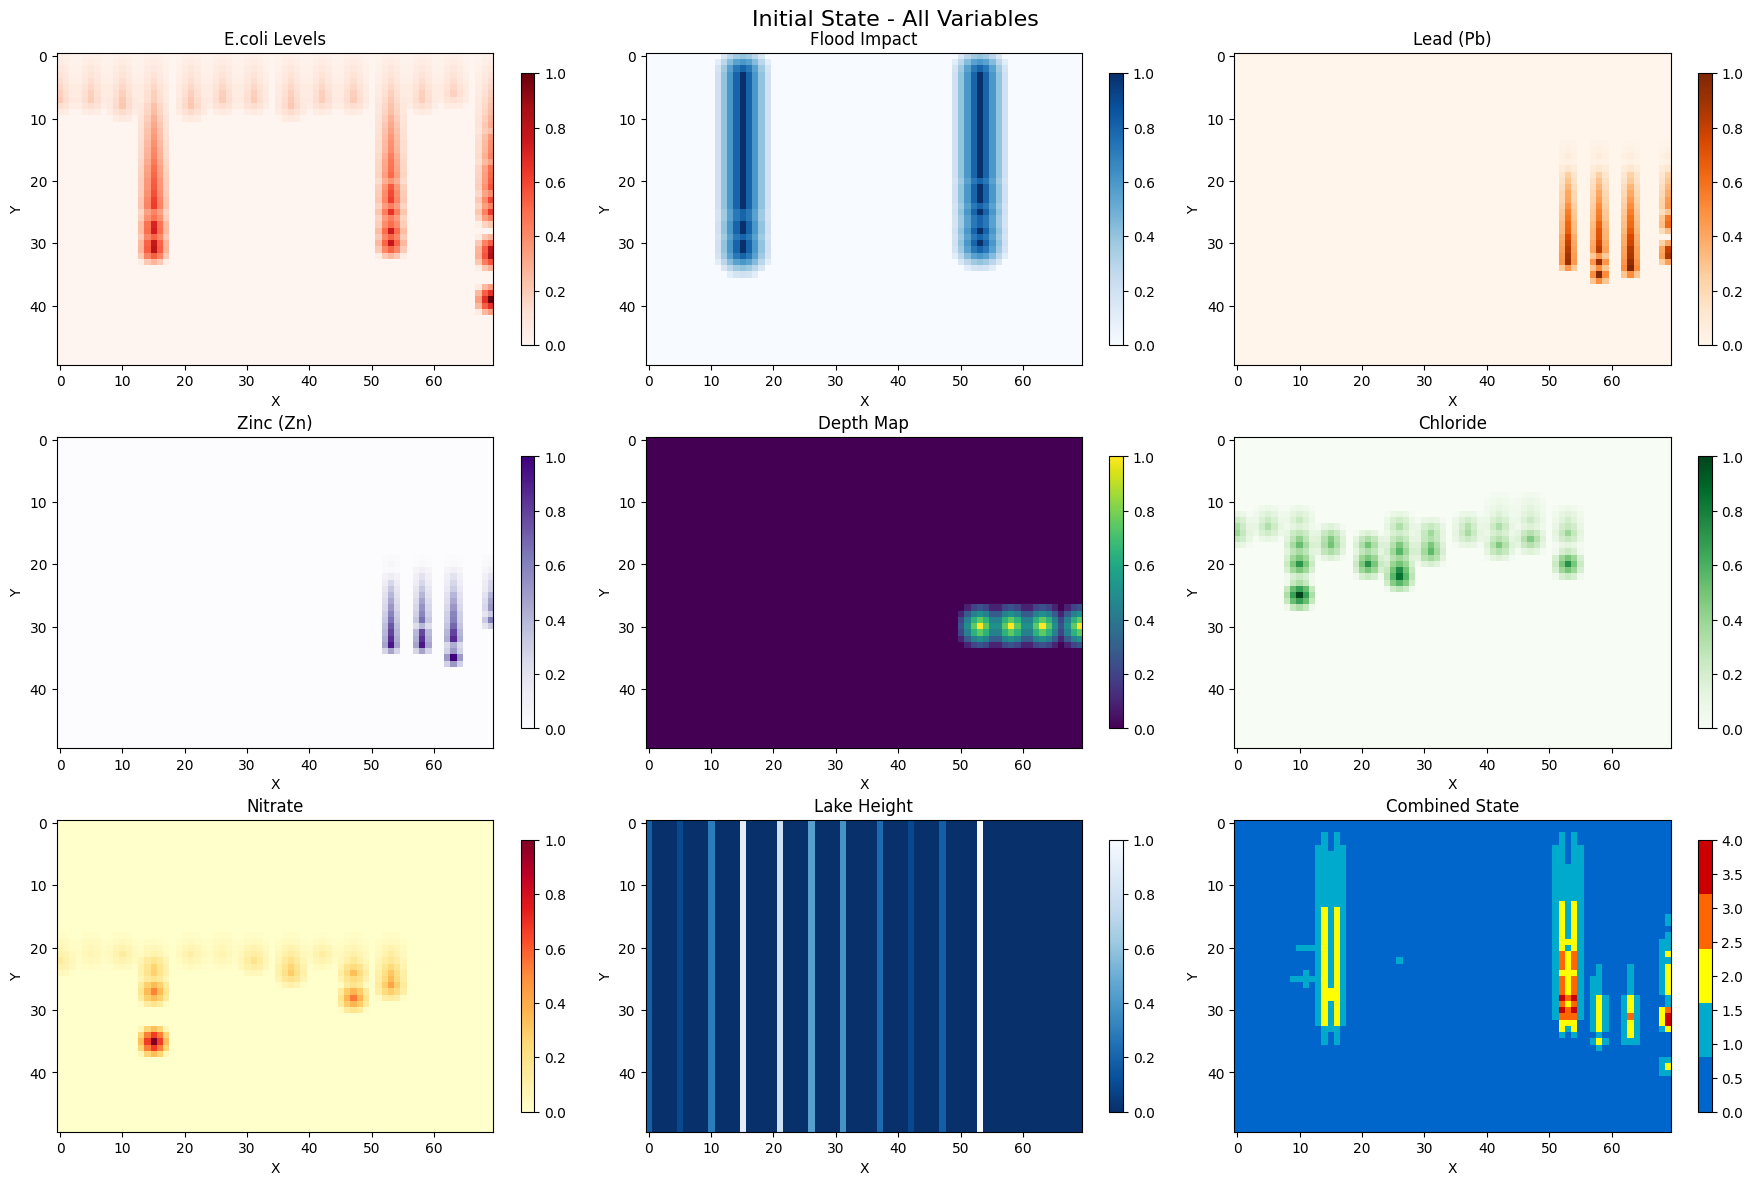

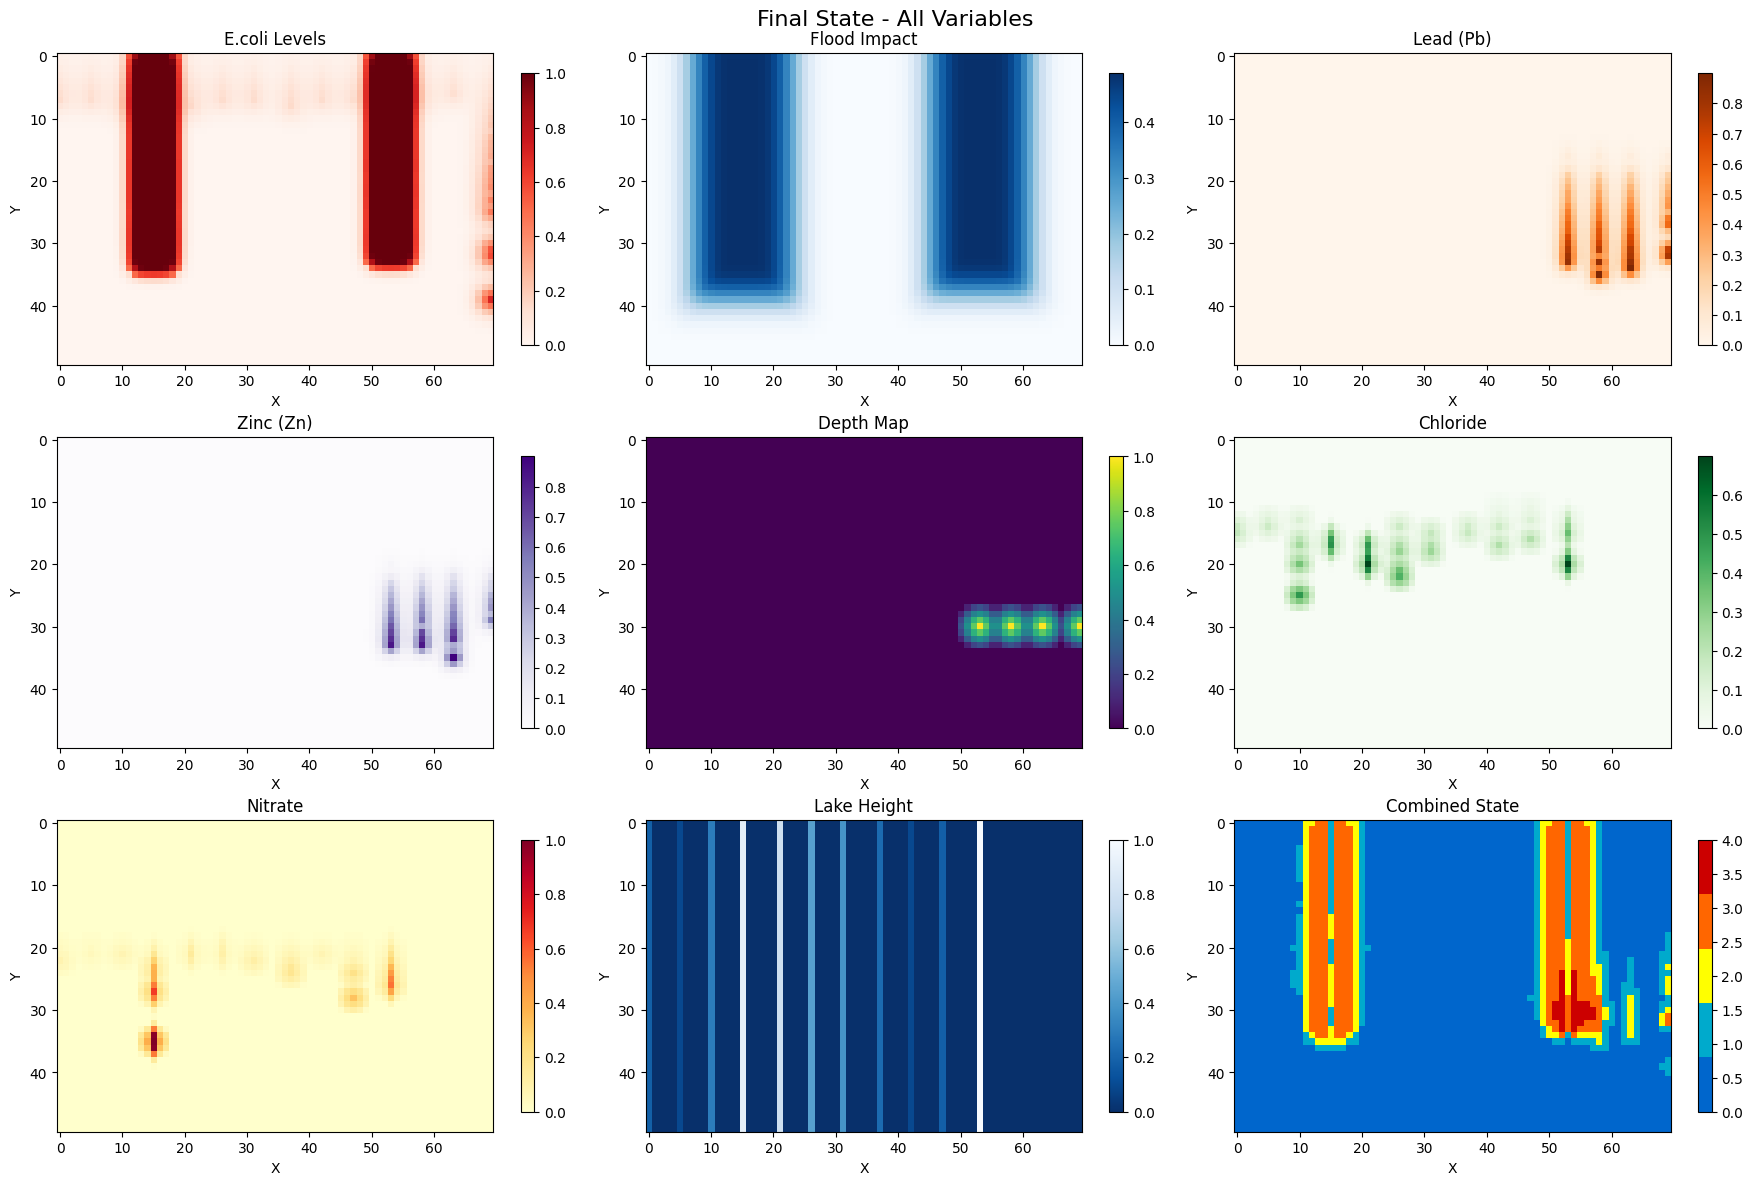

GIF saved to: kineret_firebase_2010_2023.gif


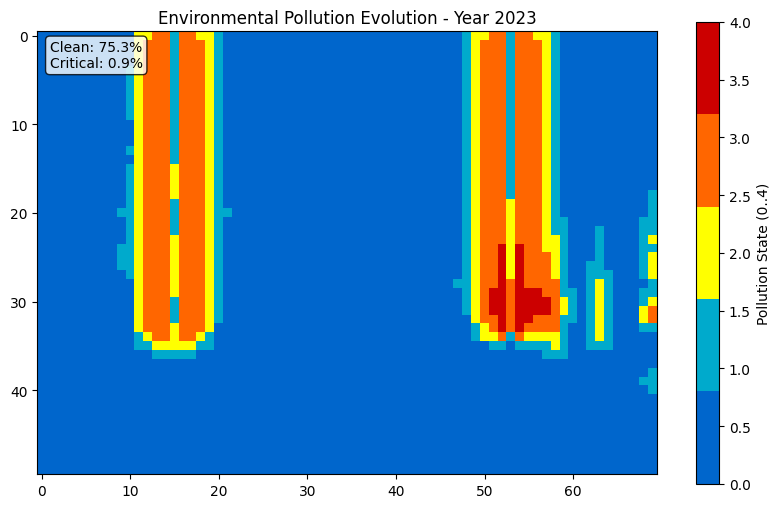

In [ ]:
def run_data_driven_simulation_firebase(firebase_data,
                                        pick_last_n_years: Optional[int]=13,
                                        restrict_range: Optional[tuple]=(2010, 2023),
                                        width=70, height=50,
                                        interval=900, fps=2,
                                        save_gif=True, gif_path="kineret_ca_slow.gif",
                                        seed: Optional[int]=42):
    """
    Run data-driven cellular automata simulation with Firebase data

    Parameters:
    - firebase_data: Data loaded from Firebase
    - pick_last_n_years: keep only the last N available years
    - restrict_range: (min_year, max_year) inclusive; None to disable
    """
    model = EcologicalCellularAutomata(width=width, height=height, seed=seed)

    if firebase_data:
        # Directly extract data from Firebase instead of loading from file
        ecoli = model._extract_ecoli_floods(firebase_data)
        metals = model._extract_heavy_metals(firebase_data)
        chems = model._extract_chemicals(firebase_data)

        # Union years across categories
        years = set()
        years.update([r['year'] for r in ecoli])
        years.update([r['year'] for r in metals])
        years.update([r['year'] for r in chems])
        model.step_years = sorted(list(years))

        model.real_data = {'ecoli': ecoli, 'metals': metals, 'chemicals': chems}

        if model.step_years:
            years_sorted = sorted(model.step_years)

            # Apply range restriction (2010-2023)
            if restrict_range is not None:
                y0, y1 = restrict_range
                years_sorted = [y for y in years_sorted if y0 <= y <= y1]
                print(f"Filtered to years {restrict_range}: {years_sorted}")

            # Pick last N years
            if pick_last_n_years is not None and pick_last_n_years > 0:
                years_sorted = years_sorted[-pick_last_n_years:] or years_sorted

            model.step_years = years_sorted
            model.initialize_from_data()
            print(f"Using Firebase data. Years analyzed: {model.step_years}")
            print(f"Total years: {len(model.step_years)}")
        else:
            print("No valid years found in Firebase data")
            model.create_synthetic_scenario()
    else:
        model.create_synthetic_scenario()
        print("No Firebase data - using synthetic scenario.")

    # Initial visualization
    model.visualize_variables("Initial State - All Variables")

    # Run simulation
    steps_to_run = len(model.step_years) if model.step_years else 25
    model.run_simulation(steps=steps_to_run)

    # Final visualization
    model.visualize_variables("Final State - All Variables")

    # Create animation
    anim = model.create_animation(interval=interval, fps=fps, show_inline=True)

    # Save GIF
    if save_gif and anim is not None:
        model.export_gif(path=gif_path, fps=fps, dpi=140)

    return model, anim

# Usage with your Firebase data:
if has_real_data and data:
    print("Running Cellular Automata Simulation with Firebase data (2010-2023)...")
    ca_model, ca_animation = run_data_driven_simulation_firebase(
        firebase_data=data,
        pick_last_n_years=14,  # 2010-2023 is 14 years
        restrict_range=(2010, 2023),
        width=70, height=50,
        interval=900,
        fps=2,
        save_gif=True,
        gif_path="kineret_firebase_2010_2023.gif",
        seed=42
    )
else:
    print("No Firebase data available")

## Summary and Results

This notebook provides a comprehensive analysis of Lake Kinneret environmental data through three main approaches:

1. **PCA Analysis**: Identifies key relationships between environmental variables
2. **Cellular Automata**: Models dynamic pollution spread and recovery patterns
3. **Scenario Analysis**: Visualizes baseline, stress, and recovery scenarios

The analysis integrates multiple data sources to provide insights into lake ecosystem health and management strategies.